In [1]:
# ============================================================
# Cell 1: Imports & Environment Sanity Check
# ============================================================

# ---- Standard library ----
import os
import sys
import json
import time
import math
import random
from pathlib import Path
from collections import defaultdict

# ---- Numerical / scientific ----
import numpy as np
import pandas as pd

# ---- Image processing ----
import cv2
from PIL import Image

# ---- Deep learning ----
import torch
import torchvision
from torchvision.ops import box_convert

# ---- RF-DETR ----
from rfdetr import RFDETRNano

# ---- Dataset / evaluation ----
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# ---- Augmentation / preprocessing ----
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---- Visualization ----
import matplotlib.pyplot as plt

# ---- Utilities ----
from tqdm import tqdm
import psutil
import yaml

# ============================================================
# Reproducibility helper
# ============================================================

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ============================================================
# Environment sanity prints
# ============================================================

print("=== Environment Check ===")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"Torchvision version : {torchvision.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(f"CPU cores           : {psutil.cpu_count(logical=True)}")
print(f"Random seed         : {SEED}")
print("=========================")

=== Environment Check ===
Python version      : 3.11.9
PyTorch version     : 2.5.1+cu121
Torchvision version : 0.20.1+cu121
CUDA available      : True
CUDA version        : 12.1
GPU                 : NVIDIA GeForce RTX 3090
CPU cores           : 16
Random seed         : 42


In [2]:
# ============================================================
# Cell 2: Canonical Class Mapping (VisDrone-VID -> Phase 3 Classes)
# SINGLE SOURCE OF TRUTH
# ============================================================

# ---- Phase 3 canonical classes ----
PHASE3_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

NUM_CLASSES = len(PHASE3_CLASSES)

# ---- Ordered canonical class names (index = class_id - 1) ----
PHASE3_CLASS_NAMES = [PHASE3_CLASSES[i] for i in range(1, NUM_CLASSES + 1)]

# ---- Inverse mapping (name -> id) ----
PHASE3_CLASS_NAME_TO_ID = {name: idx for idx, name in PHASE3_CLASSES.items()}

# ---- Official-ish VisDrone-VID / MOT source categories ----
# These are NOT the same as the still-image VisDrone label IDs.
VISDRONE_VID_CLASSES = {
    0: "ignored_regions",
    1: "pedestrian",
    2: "people",
    3: "bicycle",
    4: "car",
    5: "van",
    6: "truck",
    7: "tricycle",
    8: "awning-tricycle",
    9: "bus",
    10: "motor",
    11: "others",
}

# ---- VisDrone-VID -> Phase 3 mapping ----
# Important:
# - 0 ("ignored_regions") must be skipped
# - 11 ("others") is skipped here rather than supervised
VISDRONE_VID_TO_PHASE3 = {
    1: PHASE3_CLASS_NAME_TO_ID["Human"],    # pedestrian -> Human
    2: PHASE3_CLASS_NAME_TO_ID["Human"],    # people -> Human
    3: PHASE3_CLASS_NAME_TO_ID["Bicycle"],  # bicycle -> Bicycle
    4: PHASE3_CLASS_NAME_TO_ID["Car"],      # car -> Car
    5: PHASE3_CLASS_NAME_TO_ID["Car"],      # van -> Car
    6: PHASE3_CLASS_NAME_TO_ID["Truck"],    # truck -> Truck
    7: PHASE3_CLASS_NAME_TO_ID["Truck"],    # tricycle -> Truck (project decision)
    8: PHASE3_CLASS_NAME_TO_ID["Car"],      # awning-tricycle -> Car (project decision)
    9: PHASE3_CLASS_NAME_TO_ID["Bus"],      # bus -> Bus
    10: PHASE3_CLASS_NAME_TO_ID["Other"],   # motor -> Other
}

# ---- Which source rows are valid for training? ----
# VisDrone-VID rows with score != 1 should be skipped.
VALID_VID_SCORE_VALUES = {1}

# Optional metadata tag so downstream cells can force rebuilds
SOURCE_LABEL_SPACE_NAME = "visdrone_vid_v2"
SOURCE_LABEL_SPACE_VERSION = 2

# ---- COCO category definition (derive here, from the canonical source) ----
COCO_CATEGORIES = [
    {
        "id": class_id,
        "name": class_name,
        "supercategory": "object",
    }
    for class_id, class_name in PHASE3_CLASSES.items()
]

# ---- Metadata helpers for later cells ----
DATASET_METADATA = {
    "num_classes": NUM_CLASSES,
    "class_id_to_name": PHASE3_CLASSES,
    "class_name_to_id": PHASE3_CLASS_NAME_TO_ID,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,
    "source_label_space_name": SOURCE_LABEL_SPACE_NAME,
    "source_label_space_version": SOURCE_LABEL_SPACE_VERSION,
}

def class_id_to_name(class_id: int) -> str:
    return PHASE3_CLASSES.get(int(class_id), f"unknown_{class_id}")

# ============================================================
# Sanity checks
# ============================================================

assert sorted(PHASE3_CLASSES.keys()) == list(range(1, NUM_CLASSES + 1))
assert len(PHASE3_CLASS_NAMES) == NUM_CLASSES

for i, name in enumerate(PHASE3_CLASS_NAMES, start=1):
    assert PHASE3_CLASSES[i] == name

assert [c["id"] for c in COCO_CATEGORIES] == list(range(1, NUM_CLASSES + 1))
assert [c["name"] for c in COCO_CATEGORIES] == PHASE3_CLASS_NAMES

assert all(mapped_id in PHASE3_CLASSES for mapped_id in VISDRONE_VID_TO_PHASE3.values())
assert 0 not in VISDRONE_VID_TO_PHASE3, "ignored_regions must not be supervised"
assert 11 not in VISDRONE_VID_TO_PHASE3, "others is currently configured to be skipped"

print("=== Phase 3 Class Mapping Locked (VisDrone-VID) ===")
print(f"Number of classes: {NUM_CLASSES}\n")

print("Phase 3 Classes:")
for k, v in PHASE3_CLASSES.items():
    print(f"  {k}: {v}")

print("\nOrdered class names:")
for i, name in enumerate(PHASE3_CLASS_NAMES, start=1):
    print(f"  {i}: {name}")

print("\nVisDrone-VID Source Classes:")
for k, v in VISDRONE_VID_CLASSES.items():
    print(f"  {k:>2}: {v}")

print("\nVisDrone-VID -> Phase 3 Mapping:")
for vd_id, p3_id in VISDRONE_VID_TO_PHASE3.items():
    print(
        f"  VisDrone-VID {vd_id:>2} ({VISDRONE_VID_CLASSES[vd_id]:<17}) "
        f"-> Phase 3 {p3_id} ({PHASE3_CLASSES[p3_id]})"
    )

print("\nIgnored / skipped source classes:")
for skipped_id in sorted(set(VISDRONE_VID_CLASSES.keys()) - set(VISDRONE_VID_TO_PHASE3.keys())):
    print(f"  {skipped_id:>2}: {VISDRONE_VID_CLASSES[skipped_id]}")

print("\nValid score values for training rows:", VALID_VID_SCORE_VALUES)

print("\nCOCO Categories:")
for cat in COCO_CATEGORIES:
    print(f"  id={cat['id']} | name={cat['name']}")

print("===================================")

=== Phase 3 Class Mapping Locked (VisDrone-VID) ===
Number of classes: 6

Phase 3 Classes:
  1: Human
  2: Bicycle
  3: Car
  4: Truck
  5: Bus
  6: Other

Ordered class names:
  1: Human
  2: Bicycle
  3: Car
  4: Truck
  5: Bus
  6: Other

VisDrone-VID Source Classes:
   0: ignored_regions
   1: pedestrian
   2: people
   3: bicycle
   4: car
   5: van
   6: truck
   7: tricycle
   8: awning-tricycle
   9: bus
  10: motor
  11: others

VisDrone-VID -> Phase 3 Mapping:
  VisDrone-VID  1 (pedestrian       ) -> Phase 3 1 (Human)
  VisDrone-VID  2 (people           ) -> Phase 3 1 (Human)
  VisDrone-VID  3 (bicycle          ) -> Phase 3 2 (Bicycle)
  VisDrone-VID  4 (car              ) -> Phase 3 3 (Car)
  VisDrone-VID  5 (van              ) -> Phase 3 3 (Car)
  VisDrone-VID  6 (truck            ) -> Phase 3 4 (Truck)
  VisDrone-VID  7 (tricycle         ) -> Phase 3 4 (Truck)
  VisDrone-VID  8 (awning-tricycle  ) -> Phase 3 3 (Car)
  VisDrone-VID  9 (bus              ) -> Phase 3 5 (Bus)


In [3]:
# ============================================================
# Cell 3: VisDrone RGB Video Dataset Paths & Structure Validation
# ============================================================

# ---- Project roots ----
# Assumes notebook is run from:
# object-identification-uav-camera/rfdetr_training_rgb_video.ipynb
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR

VISDRONE_VIDEO_ROOT = PROJECT_ROOT / "visdrone-dataset-rgb-videos"

# ---- Expected dataset splits ----
VISDRONE_VIDEO_SPLITS = {
    "train": VISDRONE_VIDEO_ROOT / "train",
    "val": VISDRONE_VIDEO_ROOT / "val",
    "test-dev": VISDRONE_VIDEO_ROOT / "test-dev",
}

# ---- Expected subfolders inside each split ----
SEQUENCES_DIRNAME = "sequences"
ANN_DIRNAME = "annotations"

# ---- Reusable structure summary ----
DATASET_STRUCTURE = {}

print("=== VisDrone RGB Video Dataset Structure Check ===\n")
print(f"Notebook dir        : {NOTEBOOK_DIR}")
print(f"Project root        : {PROJECT_ROOT}")
print(f"VisDrone video root : {VISDRONE_VIDEO_ROOT}\n")

assert VISDRONE_VIDEO_ROOT.exists(), f"VisDrone video root not found: {VISDRONE_VIDEO_ROOT}"

for split, split_path in VISDRONE_VIDEO_SPLITS.items():
    print(f"[{split.upper()}]")
    print(f"Path: {split_path}")

    assert split_path.exists(), f"Missing split directory: {split_path}"

    sequences_dir = split_path / SEQUENCES_DIRNAME
    ann_dir = split_path / ANN_DIRNAME

    assert sequences_dir.exists(), f"Missing sequences directory: {sequences_dir}"
    assert ann_dir.exists(), f"Missing annotations directory: {ann_dir}"

    # ---- Video sequence folders ----
    sequence_dirs = sorted([p for p in sequences_dir.iterdir() if p.is_dir()])
    ann_files = sorted(ann_dir.glob("*.txt"))

    num_sequences = len(sequence_dirs)
    num_ann_files = len(ann_files)

    print(f"SUCCESS: Sequences directory found ({num_sequences} sequence folders)")
    print(f"SUCCESS: Annotations directory found ({num_ann_files} annotation files)")

    if num_sequences != num_ann_files:
        raise ValueError(
            f"Sequence / annotation count mismatch in split '{split}': "
            f"{num_sequences} sequence folders vs {num_ann_files} annotation files"
        )

    # ---- Sequence folder name / annotation stem consistency check ----
    sequence_names = {p.name for p in sequence_dirs}
    ann_stems = {p.stem for p in ann_files}

    missing_ann = sorted(sequence_names - ann_stems)
    missing_seq = sorted(ann_stems - sequence_names)

    if missing_ann or missing_seq:
        raise ValueError(
            f"Sequence-folder / annotation stem mismatch in split '{split}'.\n"
            f"Sequences without annotation txt: {missing_ann[:5]}\n"
            f"Annotation txt without sequence folder: {missing_seq[:5]}"
        )

    print("SUCCESS: Sequence / annotation counts match")
    print("SUCCESS: Sequence folder names match annotation stems")

    # ---- Per-sequence frame validation ----
    total_frames = 0
    empty_sequences = []
    non_jpg_frame_sequences = []
    frame_count_by_sequence = {}

    for seq_dir in sequence_dirs:
        jpg_frames = sorted(seq_dir.glob("*.jpg"))
        frame_count = len(jpg_frames)
        frame_count_by_sequence[seq_dir.name] = frame_count
        total_frames += frame_count

        if frame_count == 0:
            empty_sequences.append(seq_dir.name)

        # check for unexpected non-jpg files
        other_files = [p.name for p in seq_dir.iterdir() if p.is_file() and p.suffix.lower() != ".jpg"]
        if other_files:
            non_jpg_frame_sequences.append({
                "sequence": seq_dir.name,
                "sample_non_jpg_files": other_files[:5],
            })

    if empty_sequences:
        raise ValueError(
            f"Found empty sequence folders in split '{split}'. "
            f"Examples: {empty_sequences[:5]}"
        )

    if non_jpg_frame_sequences:
        print("WARNING: Found non-.jpg files inside some sequence folders.")
        for item in non_jpg_frame_sequences[:5]:
            print(f"  {item['sequence']}: {item['sample_non_jpg_files']}")

    print(f"SUCCESS: All sequence folders contain at least one .jpg frame")
    print(f"Total frames across sequences: {total_frames}")

    # ---- Annotation file sanity preview ----
    annotation_line_counts = {}
    malformed_annotation_files = []

    for ann_file in ann_files:
        with open(ann_file, "r", encoding="utf-8") as f:
            lines = [ln.strip() for ln in f if ln.strip()]

        annotation_line_counts[ann_file.stem] = len(lines)

        # VisDrone-VID annotations are expected to be comma-separated rows.
        # We only do a light structural check here.
        for i, line in enumerate(lines[:10], start=1):
            parts = [x.strip() for x in line.split(",")]
            if len(parts) < 8:
                malformed_annotation_files.append({
                    "file": ann_file.name,
                    "line_number": i,
                    "line": line,
                })
                break

    if malformed_annotation_files:
        raise ValueError(
            f"Found malformed annotation rows in split '{split}'. "
            f"Examples: {malformed_annotation_files[:5]}"
        )

    print("SUCCESS: Annotation files passed basic row-format sanity check")

    # ---- Save split summary ----
    DATASET_STRUCTURE[split] = {
        "split_path": split_path,
        "sequences_dir": sequences_dir,
        "ann_dir": ann_dir,
        "num_sequences": num_sequences,
        "num_annotation_files": num_ann_files,
        "total_frames": total_frames,
        "sequence_dirs": sequence_dirs,
        "annotation_files": ann_files,
        "frame_count_by_sequence": frame_count_by_sequence,
        "annotation_line_counts": annotation_line_counts,
    }

    # ---- Short preview ----
    preview_sequences = sorted(frame_count_by_sequence.items(), key=lambda x: x[0])[:5]
    print("Sequence preview (name -> #frames):")
    for seq_name, frame_count in preview_sequences:
        print(f"  {seq_name}: {frame_count}")

    print()

print("=== Structure Check Complete ===")

=== VisDrone RGB Video Dataset Structure Check ===

Notebook dir        : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera
Project root        : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera
VisDrone video root : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/visdrone-dataset-rgb-videos

[TRAIN]
Path: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/visdrone-dataset-rgb-videos/train
SUCCESS: Sequences directory found (56 sequence folders)
SUCCESS: Annotations directory found (56 annotation files)
SUCCESS: Sequence / annotation counts match
SUCCESS: Sequence folder names match annotation stems
SUCCESS: All sequence folders contain at least one .jpg frame
Total frames across sequences: 24201
SUCCESS: Annotation files passed basic row-format sanity check
Sequence preview (name -> #frames):
  uav0000013_00000_v:

Inspecting annotation file : uav0000307_00000_v.txt
Corresponding sequence     : uav0000307_00000_v
Total frames in sequence   : 414
Total raw annotation rows  : 7771

Chosen frame_id            : 328
Resolved frame image       : 0000328.jpg
Image size                 : 1904 x 1071
Annotated rows in frame    : 14

Obj 00: frame_id=328, target_id=47, score=1, VisDrone-VID class=4 (car), phase3=3 (Car), Box=(x=915, y=829, w=182, h=135), trunc=0, occ=0
SKIP Obj 01: target_id=48, score=0, cls=0 (ignored_regions), reason=ignored_by_score
Obj 02: frame_id=328, target_id=50, score=1, VisDrone-VID class=4 (car), phase3=3 (Car), Box=(x=0, y=888, w=264, h=181), trunc=1, occ=0
Obj 03: frame_id=328, target_id=51, score=1, VisDrone-VID class=4 (car), phase3=3 (Car), Box=(x=839, y=613, w=128, h=82), trunc=0, occ=0
Obj 04: frame_id=328, target_id=52, score=1, VisDrone-VID class=4 (car), phase3=3 (Car), Box=(x=634, y=637, w=147, h=84), trunc=0, occ=0
Obj 05: frame_id=328, target_id=53, score=1, VisDro

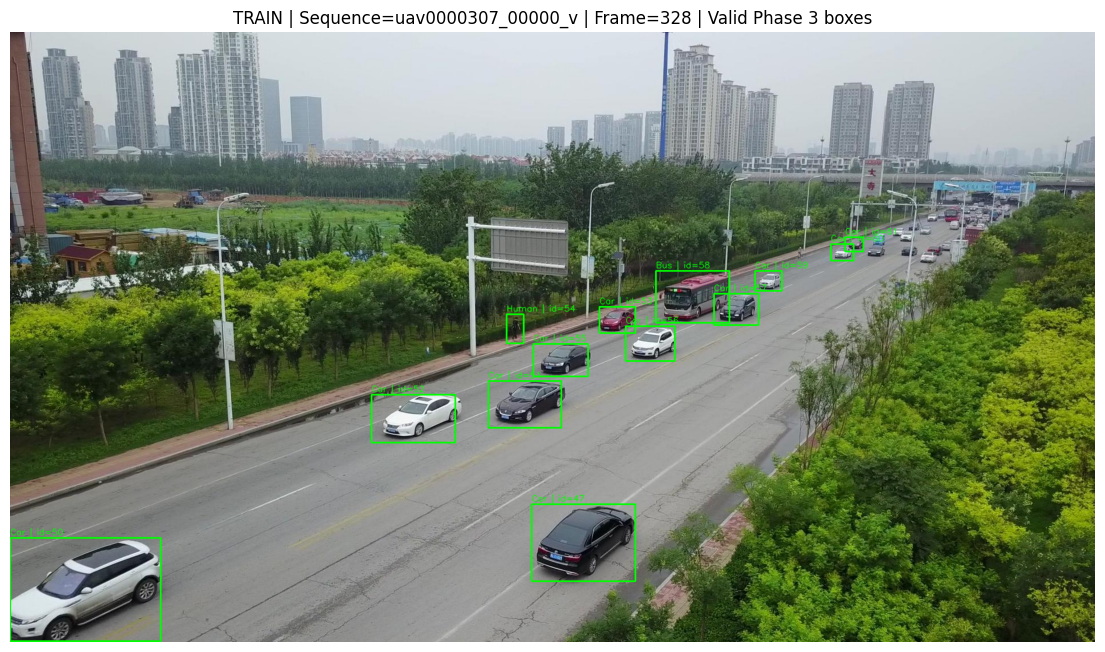

In [4]:
# ============================================================
# Cell 4: Inspect One VisDrone-VID Annotation File + Visualize
# Boxes for One Frame
# Robust parsing + score/class-remap sanity check
# ============================================================

INSPECT_SPLIT = "train"

# Optional: set to a specific sequence name like "uav0000013_00000_v"
INSPECT_SEQUENCE = None

# Optional: set to a specific frame index (1-based)
INSPECT_FRAME_ID = None

sequences_dir = DATASET_STRUCTURE[INSPECT_SPLIT]["sequences_dir"]
ann_dir = DATASET_STRUCTURE[INSPECT_SPLIT]["ann_dir"]

ann_files = sorted(ann_dir.glob("*.txt"))
assert len(ann_files) > 0, f"No annotation files found in: {ann_dir}"

if INSPECT_SEQUENCE is not None:
    sample_ann_file = ann_dir / f"{INSPECT_SEQUENCE}.txt"
    assert sample_ann_file.exists(), f"Annotation file not found: {sample_ann_file}"
else:
    rng = random.Random(SEED)
    sample_ann_file = rng.choice(ann_files)

sequence_name = sample_ann_file.stem
sequence_dir = sequences_dir / sequence_name

assert sequence_dir.exists(), f"Sequence folder not found: {sequence_dir}"

frame_files = sorted(sequence_dir.glob("*.jpg"))
assert len(frame_files) > 0, f"No .jpg frames found in: {sequence_dir}"

print(f"Inspecting annotation file : {sample_ann_file.name}")
print(f"Corresponding sequence     : {sequence_name}")
print(f"Total frames in sequence   : {len(frame_files)}")

with open(sample_ann_file, "r", encoding="utf-8") as f:
    raw_lines = [l.strip() for l in f.readlines() if l.strip()]

print(f"Total raw annotation rows  : {len(raw_lines)}\n")

rows_by_frame = defaultdict(list)
skip_reasons_global = defaultdict(int)

for idx, line in enumerate(raw_lines):
    parts = [p.strip() for p in line.split(",")]

    if len(parts) < 10:
        skip_reasons_global["malformed_row_too_few_columns"] += 1
        continue

    try:
        frame_id = int(parts[0])
        target_id = int(parts[1])
        x = int(float(parts[2]))
        y = int(float(parts[3]))
        w = int(float(parts[4]))
        h = int(float(parts[5]))
        score = int(float(parts[6]))
        vd_cls = int(float(parts[7]))
        trunc = int(float(parts[8]))
        occ = int(float(parts[9]))
    except ValueError:
        skip_reasons_global["non_numeric_row"] += 1
        continue

    rows_by_frame[frame_id].append({
        "row_index": idx,
        "frame_id": frame_id,
        "target_id": target_id,
        "x": x,
        "y": y,
        "w": w,
        "h": h,
        "score": score,
        "vd_cls": vd_cls,
        "trunc": trunc,
        "occ": occ,
        "raw_line": line,
    })

valid_frame_ids = sorted(rows_by_frame.keys())
assert len(valid_frame_ids) > 0, f"No usable annotation rows found in: {sample_ann_file}"

if INSPECT_FRAME_ID is not None:
    chosen_frame_id = INSPECT_FRAME_ID
    assert chosen_frame_id in rows_by_frame, (
        f"Requested frame_id={chosen_frame_id} not found in annotation file."
    )
else:
    candidate_frame_ids = []
    for frame_id in valid_frame_ids:
        frame_rows = rows_by_frame[frame_id]
        has_valid = any(
            (
                r["score"] in VALID_VID_SCORE_VALUES and
                r["vd_cls"] in VISDRONE_VID_TO_PHASE3 and
                r["w"] > 0 and
                r["h"] > 0
            )
            for r in frame_rows
        )
        if has_valid:
            candidate_frame_ids.append(frame_id)

    rng = random.Random(SEED)
    chosen_frame_id = rng.choice(candidate_frame_ids if candidate_frame_ids else valid_frame_ids)

print(f"Chosen frame_id            : {chosen_frame_id}")

candidate_frame_names = [
    f"{chosen_frame_id:07d}.jpg",
    f"{chosen_frame_id:06d}.jpg",
    f"{chosen_frame_id:08d}.jpg",
    f"{chosen_frame_id}.jpg",
]

sample_frame_file = None
for name in candidate_frame_names:
    p = sequence_dir / name
    if p.exists():
        sample_frame_file = p
        break

if sample_frame_file is None:
    raise FileNotFoundError(
        f"Could not resolve frame image for frame_id={chosen_frame_id} in {sequence_dir}. "
        f"Tried: {candidate_frame_names}"
    )

print(f"Resolved frame image       : {sample_frame_file.name}")

img = cv2.imread(str(sample_frame_file))
assert img is not None, f"Failed to load image: {sample_frame_file}"

img_vis = img.copy()
h_img, w_img, _ = img.shape
print(f"Image size                 : {w_img} x {h_img}")

frame_rows = rows_by_frame[chosen_frame_id]

print(f"Annotated rows in frame    : {len(frame_rows)}\n")

drawn = 0
skip_reasons = defaultdict(int)
phase3_counts = defaultdict(int)

for obj_idx, row in enumerate(frame_rows):
    x = row["x"]
    y = row["y"]
    w = row["w"]
    h = row["h"]
    score = row["score"]
    vd_cls = row["vd_cls"]
    trunc = row["trunc"]
    occ = row["occ"]
    target_id = row["target_id"]

    # ---- Skip ignored rows ----
    if score not in VALID_VID_SCORE_VALUES:
        skip_reasons[f"invalid_score_{score}"] += 1
        print(
            f"SKIP Obj {obj_idx:02d}: target_id={target_id}, "
            f"score={score}, cls={vd_cls} ({VISDRONE_VID_CLASSES.get(vd_cls, 'UNKNOWN')}), "
            f"reason=ignored_by_score"
        )
        continue

    if vd_cls not in VISDRONE_VID_TO_PHASE3:
        skip_reasons["ignored_or_unmapped_source_class"] += 1
        print(
            f"SKIP Obj {obj_idx:02d}: target_id={target_id}, "
            f"score={score}, cls={vd_cls} ({VISDRONE_VID_CLASSES.get(vd_cls, 'UNKNOWN')}), "
            f"reason=ignored_or_unmapped_source_class"
        )
        continue

    if w <= 0 or h <= 0:
        skip_reasons["non_positive_box"] += 1
        continue

    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(w_img - 1, x + w)
    y2 = min(h_img - 1, y + h)

    if x2 <= x1 or y2 <= y1:
        skip_reasons["box_out_of_bounds_after_clip"] += 1
        continue

    phase3_cls = VISDRONE_VID_TO_PHASE3[vd_cls]
    cls_name = PHASE3_CLASSES[phase3_cls]
    phase3_counts[cls_name] += 1

    print(
        f"Obj {obj_idx:02d}: "
        f"frame_id={chosen_frame_id}, "
        f"target_id={target_id}, "
        f"score={score}, "
        f"VisDrone-VID class={vd_cls} ({VISDRONE_VID_CLASSES.get(vd_cls, 'UNKNOWN')}), "
        f"phase3={phase3_cls} ({cls_name}), "
        f"Box=(x={x}, y={y}, w={w}, h={h}), "
        f"trunc={trunc}, occ={occ}"
    )

    cv2.rectangle(
        img_vis,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv2.putText(
        img_vis,
        f"{cls_name} | id={target_id}",
        (x1, max(15, y1 - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

    drawn += 1

print("\n=== Inspection Summary ===")
print(f"Drawn objects: {drawn}")
print(f"Skipped total: {sum(skip_reasons.values())}")

if skip_reasons_global:
    print("\nGlobal file-level skip reasons:")
    for reason, count in sorted(skip_reasons_global.items()):
        print(f"  {reason}: {count}")

if skip_reasons:
    print("\nFrame-level skip reasons:")
    for reason, count in sorted(skip_reasons.items()):
        print(f"  {reason}: {count}")

if phase3_counts:
    print("\nPhase 3 class counts in this frame:")
    for cls_name in PHASE3_CLASS_NAMES:
        print(f"  {cls_name:<8}: {phase3_counts.get(cls_name, 0)}")

img_vis = cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14, 9))
plt.imshow(img_vis)
plt.axis("off")
plt.title(
    f"{INSPECT_SPLIT.upper()} | Sequence={sequence_name} | "
    f"Frame={chosen_frame_id} | Valid Phase 3 boxes"
)
plt.show()

In [5]:
# ============================================================
# Cell 5: COCO Schema View + Preprocessing Contract
# ============================================================

print("=== COCO Categories (Canonical) ===")
for cat in COCO_CATEGORIES:
    print(f"  id={cat['id']} | name={cat['name']}")
print("===================================\n")

# ---- Target input resolution for RF-DETR Nano ----
# For this RGB-video continuation stage, match the stronger training setup.
TARGET_IMAGE_SIZE = 512

print(f"Target model input resolution: {TARGET_IMAGE_SIZE} x {TARGET_IMAGE_SIZE}\n")

# ---- Preprocessing policy (RGB VIDEO TRAINING CONTRACT) ----
PREPROCESSING_POLICY = {
    "image": {
        "target_size": TARGET_IMAGE_SIZE,
        "resize_enabled": True,
        "resize_method": "resize_longest_side_then_pad",
        "preserve_aspect_ratio": True,
        "pad_value": 0,
    },
    "boxes": {
        "scale_boxes": True,
        "clip_boxes_to_image": True,
        "filter_non_positive_boxes": True,
        "min_box_area_px_after_resize": 4,
    },
    "normalization": {
        "enabled": True,
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225],
    },
    "training_rgb_video": {
        "continuation_training": True,
        "source_checkpoint_dir": "models/rgb-image-training",
        "small_object_focus": True,
        "aggressive_random_crop": False,
        "heavy_downscale_augmentation": False,
        "frame_level_coco_export": True,
        "source_dataset_type": "VisDrone-VID",
    }
}

# ---- Compact metadata bundle for later cells ----
TRAINING_CONTRACT = {
    "num_classes": NUM_CLASSES,
    "class_names": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "preprocessing_policy": PREPROCESSING_POLICY,
}

print("=== Preprocessing Policy ===")
for section, cfg in PREPROCESSING_POLICY.items():
    print(f"{section}: {cfg}")
print("============================\n")

print("=== Training Contract Summary ===")
print(f"num_classes       : {TRAINING_CONTRACT['num_classes']}")
print(f"class_names       : {TRAINING_CONTRACT['class_names']}")
print(f"target_image_size : {TRAINING_CONTRACT['target_image_size']}")
print("=================================")

=== COCO Categories (Canonical) ===
  id=1 | name=Human
  id=2 | name=Bicycle
  id=3 | name=Car
  id=4 | name=Truck
  id=5 | name=Bus
  id=6 | name=Other

Target model input resolution: 512 x 512

=== Preprocessing Policy ===
image: {'target_size': 512, 'resize_enabled': True, 'resize_method': 'resize_longest_side_then_pad', 'preserve_aspect_ratio': True, 'pad_value': 0}
boxes: {'scale_boxes': True, 'clip_boxes_to_image': True, 'filter_non_positive_boxes': True, 'min_box_area_px_after_resize': 4}
normalization: {'enabled': True, 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]}
training_rgb_video: {'continuation_training': True, 'source_checkpoint_dir': 'models/rgb-image-training', 'small_object_focus': True, 'aggressive_random_crop': False, 'heavy_downscale_augmentation': False, 'frame_level_coco_export': True, 'source_dataset_type': 'VisDrone-VID'}

=== Training Contract Summary ===
num_classes       : 6
class_names       : ['Human', 'Bicycle', 'Car', 'Truck', 'Bus', 'Othe

In [6]:
# ============================================================
# Cell 6: Convert VisDrone-VID -> COCO (Frame-Level Export)
# Reuse existing COCO exports only if already present and valid
# ============================================================

COCO_OUTPUT_DIR = PROJECT_ROOT / "coco_annotations_rgb_video"
COCO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COCO_EXPORT_SUMMARY = {}

def resolve_frame_path(sequence_dir: Path, frame_id: int):
    candidate_names = [
        f"{frame_id:07d}.jpg",
        f"{frame_id:06d}.jpg",
        f"{frame_id:08d}.jpg",
        f"{frame_id}.jpg",
    ]
    for name in candidate_names:
        p = sequence_dir / name
        if p.exists():
            return p
    return None

def parse_visdrone_vid_annotation_file(ann_file: Path):
    rows = []
    malformed_count = 0
    non_numeric_count = 0

    with open(ann_file, "r", encoding="utf-8") as f:
        raw_lines = [l.strip() for l in f.readlines() if l.strip()]

    for line in raw_lines:
        parts = [p.strip() for p in line.split(",")]

        if len(parts) < 10:
            malformed_count += 1
            continue

        try:
            row = {
                "frame_id": int(float(parts[0])),
                "target_id": int(float(parts[1])),
                "x": int(float(parts[2])),
                "y": int(float(parts[3])),
                "w": int(float(parts[4])),
                "h": int(float(parts[5])),
                "score": int(float(parts[6])),
                "vd_cls": int(float(parts[7])),
                "trunc": int(float(parts[8])),
                "occ": int(float(parts[9])),
            }
            rows.append(row)
        except ValueError:
            non_numeric_count += 1

    return rows, malformed_count, non_numeric_count

def summarize_existing_coco_json(split_name: str, output_json_path: Path):
    """
    Reuse an existing COCO export only if it matches the current label-space version.
    This intentionally rejects old exports built with the wrong VisDrone-VID semantics.
    """
    if not output_json_path.exists():
        return False

    try:
        with open(output_json_path, "r", encoding="utf-8") as f:
            coco = json.load(f)

        required_top_keys = {"images", "annotations", "categories", "info"}
        missing_keys = required_top_keys - set(coco.keys())
        if missing_keys:
            print(f"[REBUILD] {split_name}: existing COCO JSON missing keys: {missing_keys}")
            return False

        info = coco.get("info", {})
        if info.get("source_label_space_name") != SOURCE_LABEL_SPACE_NAME:
            print(f"[REBUILD] {split_name}: source_label_space_name mismatch")
            return False

        if info.get("source_label_space_version") != SOURCE_LABEL_SPACE_VERSION:
            print(f"[REBUILD] {split_name}: source_label_space_version mismatch")
            return False

        exported_categories = sorted(coco["categories"], key=lambda c: c["id"])
        exported_cat_ids = [c["id"] for c in exported_categories]
        exported_cat_names = [c["name"] for c in exported_categories]

        if exported_cat_ids != list(range(1, NUM_CLASSES + 1)):
            print(f"[REBUILD] {split_name}: category IDs do not match canonical classes")
            return False

        if exported_cat_names != PHASE3_CLASS_NAMES:
            print(f"[REBUILD] {split_name}: category names do not match canonical classes")
            return False

        phase3_class_counts = defaultdict(int)
        for ann in coco["annotations"]:
            cat_id = ann["category_id"]
            if cat_id in PHASE3_CLASSES:
                phase3_class_counts[PHASE3_CLASSES[cat_id]] += 1

        sequence_names = {
            img.get("sequence_name")
            for img in coco["images"]
            if img.get("sequence_name") is not None
        }

        COCO_EXPORT_SUMMARY[split_name] = {
            "split": split_name,
            "sequences_total": len(sequence_names),
            "images_total": len(coco["images"]),
            "annotations_total": len(coco["annotations"]),
            "skip_reasons": {},
            "phase3_class_counts": dict(phase3_class_counts),
            "output_json_path": str(output_json_path),
            "reused_existing_export": True,
        }

        print(f"[REUSE] {split_name}: using existing COCO JSON -> {output_json_path}")
        print(f"         images={len(coco['images'])}, annotations={len(coco['annotations'])}")
        return True

    except Exception as e:
        print(f"[REBUILD] {split_name}: failed to reuse existing COCO JSON ({e})")
        return False

def convert_visdrone_video_split_to_coco(split_name, output_json_path):
    assert split_name in DATASET_STRUCTURE, f"Unknown split: {split_name}"

    if summarize_existing_coco_json(split_name, output_json_path):
        return

    sequences_dir = DATASET_STRUCTURE[split_name]["sequences_dir"]
    ann_dir = DATASET_STRUCTURE[split_name]["ann_dir"]

    coco = {
        "info": {
            "description": f"VisDrone-VID converted to frame-level COCO using canonical Phase 3 taxonomy ({split_name})",
            "version": "1.0",
            "split": split_name,
            "num_classes": NUM_CLASSES,
            "class_names": PHASE3_CLASS_NAMES,
            "source_dataset": "VisDrone-VID",
            "source_label_space_name": SOURCE_LABEL_SPACE_NAME,
            "source_label_space_version": SOURCE_LABEL_SPACE_VERSION,
            "valid_score_values": sorted(list(VALID_VID_SCORE_VALUES)),
        },
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": COCO_CATEGORIES,
    }

    stats = {
        "split": split_name,
        "sequences_total": 0,
        "images_total": 0,
        "annotations_total": 0,
        "skip_reasons": defaultdict(int),
        "phase3_class_counts": defaultdict(int),
    }

    annotation_id = 1
    image_id = 1

    sequence_dirs = DATASET_STRUCTURE[split_name]["sequence_dirs"]

    print(f"\n=== Converting split: {split_name} ===")
    print(f"Sequences found: {len(sequence_dirs)}")
    print(f"Output JSON    : {output_json_path}")

    for sequence_dir in tqdm(sequence_dirs, desc=f"Converting {split_name}"):
        sequence_name = sequence_dir.name
        ann_file = ann_dir / f"{sequence_name}.txt"

        stats["sequences_total"] += 1

        if not ann_file.exists():
            stats["skip_reasons"]["missing_annotation_file"] += 1
            continue

        rows, malformed_count, non_numeric_count = parse_visdrone_vid_annotation_file(ann_file)
        stats["skip_reasons"]["malformed_row"] += malformed_count
        stats["skip_reasons"]["non_numeric_row"] += non_numeric_count

        rows_by_frame = defaultdict(list)
        for row in rows:
            rows_by_frame[row["frame_id"]].append(row)

        frame_files = sorted(sequence_dir.glob("*.jpg"))
        if len(frame_files) == 0:
            stats["skip_reasons"]["empty_sequence_dir"] += 1
            continue

        for frame_file in frame_files:
            with Image.open(frame_file) as img:
                width, height = img.size

            try:
                frame_id = int(frame_file.stem)
            except ValueError:
                stats["skip_reasons"]["non_integer_frame_filename"] += 1
                continue

            coco["images"].append({
                "id": image_id,
                "file_name": f"{sequence_name}/{frame_file.name}",
                "width": width,
                "height": height,
                "sequence_name": sequence_name,
                "frame_id": frame_id,
            })
            stats["images_total"] += 1

            frame_rows = rows_by_frame.get(frame_id, [])

            for row in frame_rows:
                x = row["x"]
                y = row["y"]
                w = row["w"]
                h = row["h"]
                score = row["score"]
                vd_cls = row["vd_cls"]
                target_id = row["target_id"]

                # ---- Skip ignored rows ----
                if score not in VALID_VID_SCORE_VALUES:
                    stats["skip_reasons"][f"ignored_score_{score}"] += 1
                    continue

                if target_id < 0:
                    stats["skip_reasons"]["negative_target_id"] += 1
                    continue

                if vd_cls not in VISDRONE_VID_TO_PHASE3:
                    stats["skip_reasons"]["ignored_or_unmapped_source_class"] += 1
                    continue

                if w <= 0 or h <= 0:
                    stats["skip_reasons"]["non_positive_box"] += 1
                    continue

                x1 = max(0, x)
                y1 = max(0, y)
                x2 = min(width, x + w)
                y2 = min(height, y + h)

                clipped_w = x2 - x1
                clipped_h = y2 - y1

                if clipped_w <= 0 or clipped_h <= 0:
                    stats["skip_reasons"]["box_invalid_after_clip"] += 1
                    continue

                phase3_cls = VISDRONE_VID_TO_PHASE3[vd_cls]
                cls_name = PHASE3_CLASSES[phase3_cls]

                coco["annotations"].append({
                    "id": annotation_id,
                    "image_id": image_id,
                    "category_id": phase3_cls,
                    "bbox": [x1, y1, clipped_w, clipped_h],
                    "area": clipped_w * clipped_h,
                    "iscrowd": 0,
                    "track_id": target_id,
                    "sequence_name": sequence_name,
                    "frame_id": frame_id,
                    "truncation": row["trunc"],
                    "occlusion": row["occ"],
                    "source_score": score,
                    "source_class_id": vd_cls,
                    "source_class_name": VISDRONE_VID_CLASSES.get(vd_cls, "UNKNOWN"),
                })

                annotation_id += 1
                stats["annotations_total"] += 1
                stats["phase3_class_counts"][cls_name] += 1

            image_id += 1

    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(coco, f, indent=2)

    COCO_EXPORT_SUMMARY[split_name] = {
        "split": stats["split"],
        "sequences_total": stats["sequences_total"],
        "images_total": stats["images_total"],
        "annotations_total": stats["annotations_total"],
        "skip_reasons": dict(stats["skip_reasons"]),
        "phase3_class_counts": dict(stats["phase3_class_counts"]),
        "output_json_path": str(output_json_path),
        "reused_existing_export": False,
    }

    print(f"\nFinished {split_name}:")
    print(f"  Sequences   : {stats['sequences_total']}")
    print(f"  Images      : {stats['images_total']}")
    print(f"  Annotations : {stats['annotations_total']}")

    print("\nPer-class converted counts:")
    for cls_name in PHASE3_CLASS_NAMES:
        print(f"  {cls_name:<8}: {stats['phase3_class_counts'].get(cls_name, 0)}")

    if stats["skip_reasons"]:
        print("\nSkip reasons:")
        for reason, count in sorted(stats["skip_reasons"].items()):
            print(f"  {reason}: {count}")

    print(f"\nSaved COCO annotations to: {output_json_path}")
    print("==============================================")

convert_visdrone_video_split_to_coco(
    split_name="train",
    output_json_path=COCO_OUTPUT_DIR / "visdrone_vid_train_coco.json"
)

convert_visdrone_video_split_to_coco(
    split_name="val",
    output_json_path=COCO_OUTPUT_DIR / "visdrone_vid_val_coco.json"
)

convert_visdrone_video_split_to_coco(
    split_name="test-dev",
    output_json_path=COCO_OUTPUT_DIR / "visdrone_vid_testdev_coco.json"
)

print("\n=== COCO Export Summary ===")
for split, summary in COCO_EXPORT_SUMMARY.items():
    print(f"\n[{split.upper()}]")
    print(f"  sequences_total   : {summary['sequences_total']}")
    print(f"  images_total      : {summary['images_total']}")
    print(f"  annotations_total : {summary['annotations_total']}")
    print(f"  output_json_path  : {summary['output_json_path']}")
    print(f"  reused_existing   : {summary.get('reused_existing_export', False)}")


=== Converting split: train ===
Sequences found: 56
Output JSON    : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_rgb_video/visdrone_vid_train_coco.json


Converting train: 100%|██████████████████████████████████████████████████████████████████████████████| 56/56 [00:15<00:00,  3.70it/s]



Finished train:
  Sequences   : 56
  Images      : 24201
  Annotations : 1105516

Per-class converted counts:
  Human   : 328701
  Bicycle : 40255
  Car     : 565252
  Truck   : 58836
  Bus     : 9653
  Other   : 102819

Skip reasons:
  ignored_score_0: 63843
  malformed_row: 0
  non_numeric_row: 0

Saved COCO annotations to: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_rgb_video/visdrone_vid_train_coco.json

=== Converting split: val ===
Sequences found: 7
Output JSON    : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_rgb_video/visdrone_vid_val_coco.json


Converting val: 100%|██████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  4.32it/s]



Finished val:
  Sequences   : 7
  Images      : 2846
  Annotations : 114132

Per-class converted counts:
  Human   : 50312
  Bicycle : 6022
  Car     : 40381
  Truck   : 5128
  Bus     : 264
  Other   : 12025

Skip reasons:
  ignored_score_0: 3995
  malformed_row: 0
  non_numeric_row: 0

Saved COCO annotations to: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_rgb_video/visdrone_vid_val_coco.json

=== Converting split: test-dev ===
Sequences found: 17
Output JSON    : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_rgb_video/visdrone_vid_testdev_coco.json


Converting test-dev: 100%|███████████████████████████████████████████████████████████████████████████| 17/17 [00:04<00:00,  3.57it/s]



Finished test-dev:
  Sequences   : 17
  Images      : 6635
  Annotations : 307799

Per-class converted counts:
  Human   : 140183
  Bicycle : 3637
  Car     : 115304
  Truck   : 20429
  Bus     : 1536
  Other   : 26710

Skip reasons:
  ignored_score_0: 25901
  malformed_row: 0
  non_numeric_row: 0

Saved COCO annotations to: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_rgb_video/visdrone_vid_testdev_coco.json

=== COCO Export Summary ===

[TRAIN]
  sequences_total   : 56
  images_total      : 24201
  annotations_total : 1105516
  output_json_path  : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_rgb_video/visdrone_vid_train_coco.json
  reused_existing   : False

[VAL]
  sequences_total   : 7
  images_total      : 2846
  annotations_total : 114132
  output_json_path  : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera

Loading COCO annotations from:
/ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_annotations_rgb_video/visdrone_vid_train_coco.json

loading annotations into memory...
Done (t=7.40s)
creating index...
index created!
=== COCO Categories (Validated) ===
id=1 | name=Human
id=2 | name=Bicycle
id=3 | name=Car
id=4 | name=Truck
id=5 | name=Bus
id=6 | name=Other

=== Dataset Statistics ===
Images     : 24201
Annotations: 1105516

=== Per-Class Annotation Counts ===
Human   : 328701
Bicycle : 40255
Car     : 565252
Truck   : 58836
Bus     : 9653
Other   : 102819

=== Annotation Integrity Checks Passed ===
All category_ids are valid
All image references are valid
All boxes have positive width/height
All boxes lie within image bounds



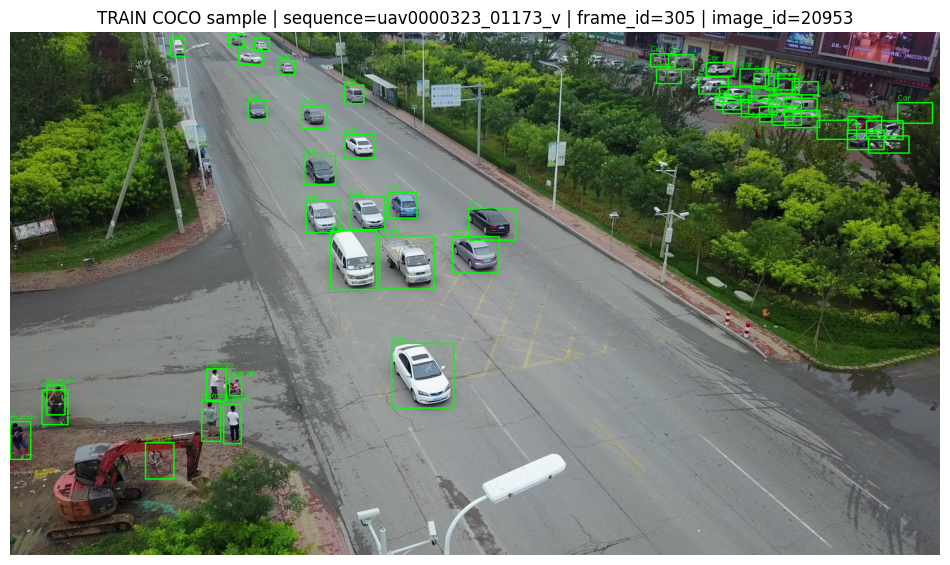

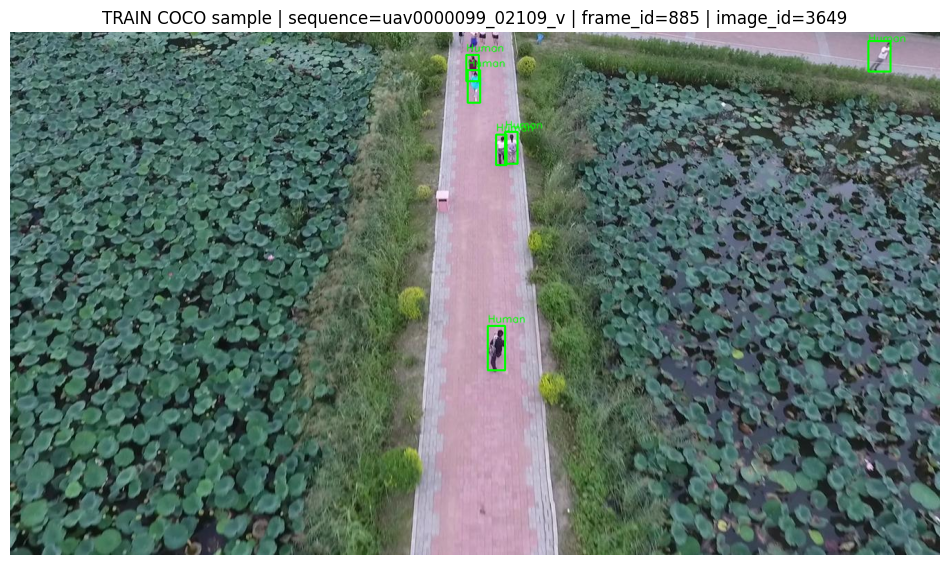

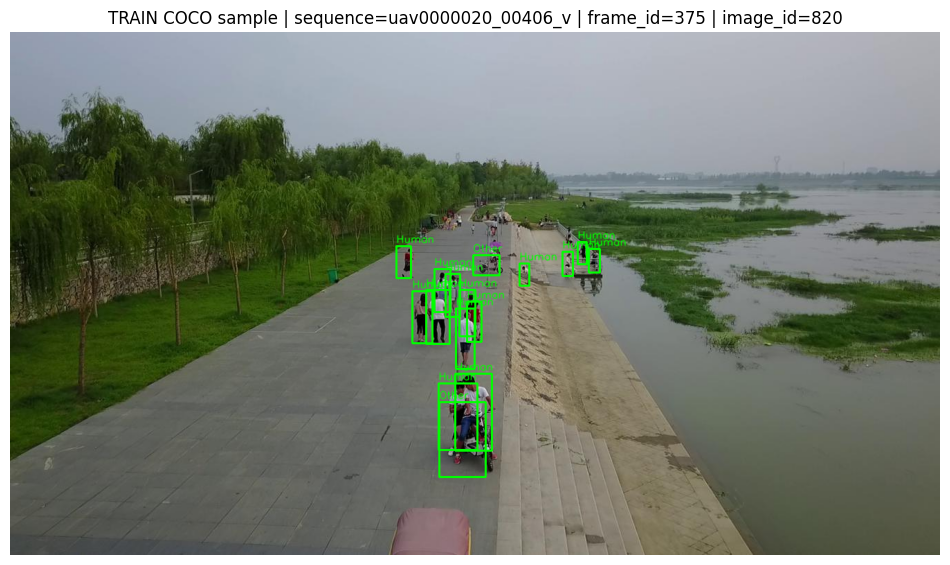

In [7]:
# ============================================================
# Cell 7: Validate COCO Output + Visual Sanity Check
# ============================================================

VALIDATE_SPLIT = "train"
COCO_JSON_PATH = COCO_OUTPUT_DIR / f"visdrone_vid_{VALIDATE_SPLIT}_coco.json"
SEQUENCES_DIR = DATASET_STRUCTURE[VALIDATE_SPLIT]["sequences_dir"]

assert COCO_JSON_PATH.exists(), f"COCO JSON not found: {COCO_JSON_PATH}"
assert SEQUENCES_DIR.exists(), f"Sequences directory not found: {SEQUENCES_DIR}"

print(f"Loading COCO annotations from:\n{COCO_JSON_PATH}\n")

coco = COCO(str(COCO_JSON_PATH))

# ---- Verify categories against canonical metadata ----
cats = sorted(coco.loadCats(coco.getCatIds()), key=lambda c: c["id"])
exported_cat_ids = [c["id"] for c in cats]
exported_cat_names = [c["name"] for c in cats]

assert exported_cat_ids == list(range(1, NUM_CLASSES + 1)), (
    f"Exported category ids mismatch.\n"
    f"Expected: {list(range(1, NUM_CLASSES + 1))}\n"
    f"Got     : {exported_cat_ids}"
)

assert exported_cat_names == PHASE3_CLASS_NAMES, (
    f"Exported category names mismatch.\n"
    f"Expected: {PHASE3_CLASS_NAMES}\n"
    f"Got     : {exported_cat_names}"
)

print("=== COCO Categories (Validated) ===")
for c in cats:
    print(f"id={c['id']} | name={c['name']}")
print("===================================\n")

# ---- Dataset statistics ----
num_images = len(coco.getImgIds())
num_annotations = len(coco.getAnnIds())

print("=== Dataset Statistics ===")
print(f"Images     : {num_images}")
print(f"Annotations: {num_annotations}")
print("==========================\n")

# ---- Cross-check against conversion summary ----
if VALIDATE_SPLIT in COCO_EXPORT_SUMMARY:
    expected_images = COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["images_total"]
    expected_annotations = COCO_EXPORT_SUMMARY[VALIDATE_SPLIT]["annotations_total"]

    assert num_images == expected_images, (
        f"Image count mismatch for split '{VALIDATE_SPLIT}'. "
        f"Expected {expected_images}, got {num_images}"
    )
    assert num_annotations == expected_annotations, (
        f"Annotation count mismatch for split '{VALIDATE_SPLIT}'. "
        f"Expected {expected_annotations}, got {num_annotations}"
    )

# ---- Per-class annotation counts ----
print("=== Per-Class Annotation Counts ===")
for c in cats:
    cat_id = c["id"]
    ann_ids = coco.getAnnIds(catIds=[cat_id])
    print(f"{c['name']:<8}: {len(ann_ids)}")
print("==================================\n")

# ---- Strong annotation sanity checks ----
all_img_ids = set(coco.getImgIds())
all_imgs = coco.loadImgs(coco.getImgIds())
all_anns = coco.loadAnns(coco.getAnnIds())

img_id_to_info = {img["id"]: img for img in all_imgs}

invalid_category_count = 0
invalid_image_ref_count = 0
invalid_box_count = 0
invalid_box_bounds_count = 0

for ann in all_anns:
    if ann["category_id"] not in PHASE3_CLASSES:
        invalid_category_count += 1

    if ann["image_id"] not in all_img_ids:
        invalid_image_ref_count += 1
        continue

    x, y, w, h = ann["bbox"]
    if w <= 0 or h <= 0:
        invalid_box_count += 1
        continue

    img_info = img_id_to_info[ann["image_id"]]
    img_w = img_info["width"]
    img_h = img_info["height"]

    if x < 0 or y < 0 or x + w > img_w + 1e-6 or y + h > img_h + 1e-6:
        invalid_box_bounds_count += 1

assert invalid_category_count == 0, f"Found {invalid_category_count} annotations with invalid category_id"
assert invalid_image_ref_count == 0, f"Found {invalid_image_ref_count} annotations with invalid image_id"
assert invalid_box_count == 0, f"Found {invalid_box_count} annotations with non-positive boxes"
assert invalid_box_bounds_count == 0, f"Found {invalid_box_bounds_count} annotations with out-of-bounds boxes"

print("=== Annotation Integrity Checks Passed ===")
print("All category_ids are valid")
print("All image references are valid")
print("All boxes have positive width/height")
print("All boxes lie within image bounds")
print("==========================================\n")

# ---- Visualize reproducible random samples ----
NUM_SAMPLES = min(3, len(coco.getImgIds()))
rng = random.Random(SEED)
sample_img_ids = rng.sample(coco.getImgIds(), NUM_SAMPLES)

for img_id in sample_img_ids:
    img_info = coco.loadImgs(img_id)[0]
    img_path = SEQUENCES_DIR / img_info["file_name"]

    img = cv2.imread(str(img_path))
    assert img is not None, f"Failed to load image: {img_path}"
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=[img_id])
    anns = coco.loadAnns(ann_ids)

    for ann in anns:
        x, y, w, h = map(int, ann["bbox"])
        cls_name = class_id_to_name(ann["category_id"])

        cv2.rectangle(
            img,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            2
        )
        cv2.putText(
            img,
            cls_name,
            (x, max(15, y - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA
        )

    plt.figure(figsize=(12, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{VALIDATE_SPLIT.upper()} COCO sample | "
        f"sequence={img_info.get('sequence_name', 'unknown')} | "
        f"frame_id={img_info.get('frame_id', 'unknown')} | image_id={img_id}"
    )
    plt.show()

In [8]:
# ============================================================
# Cell 8: Create COCO-Compatible Dataset Shim for RF-DETR
# ============================================================

import shutil

print("\n=== Creating RF-DETR COCO dataset shim for RGB-video training ===\n")

# ---- New shim root dedicated to RGB-video notebook ----
SHIM_ROOT = PROJECT_ROOT / "coco_shim_rgb_video"
COCO_TRAIN_IMG = SHIM_ROOT / "train2017"
COCO_VAL_IMG   = SHIM_ROOT / "val2017"
COCO_ANN_DIR   = SHIM_ROOT / "annotations"

COCO_TRAIN_ANN = COCO_ANN_DIR / "instances_train2017.json"
COCO_VAL_ANN   = COCO_ANN_DIR / "instances_val2017.json"

for d in [COCO_TRAIN_IMG, COCO_VAL_IMG, COCO_ANN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_SRC_JSON = COCO_OUTPUT_DIR / "visdrone_vid_train_coco.json"
VAL_SRC_JSON   = COCO_OUTPUT_DIR / "visdrone_vid_val_coco.json"

assert TRAIN_SRC_JSON.exists(), f"Missing train COCO json: {TRAIN_SRC_JSON}"
assert VAL_SRC_JSON.exists(), f"Missing val COCO json: {VAL_SRC_JSON}"

def make_flat_frame_name(sequence_name: str, original_name: str) -> str:
    return f"{sequence_name}__{original_name}"

def rewrite_coco_json_and_copy_images(src_json, dst_json, split_name, split_key, dst_img_dir):
    with open(src_json, "r", encoding="utf-8") as f:
        coco_json = json.load(f)

    sequences_dir = DATASET_STRUCTURE[split_key]["sequences_dir"]
    copied_count = 0

    for img_info in tqdm(coco_json["images"], desc=f"Preparing {split_name} shim"):
        original_rel_path = img_info["file_name"]              # e.g. seq/0000001.jpg
        sequence_name, original_name = original_rel_path.split("/", 1)

        src_img = sequences_dir / original_rel_path
        assert src_img.exists(), f"Missing source image for shim copy: {src_img}"

        flat_name = make_flat_frame_name(sequence_name, original_name)
        dst_img = dst_img_dir / flat_name

        if not dst_img.exists():
            shutil.copy2(src_img, dst_img)
            copied_count += 1

        # Rewrite file_name to flat filename expected in shim folder
        img_info["file_name"] = flat_name

    with open(dst_json, "w", encoding="utf-8") as f:
        json.dump(coco_json, f, indent=2)

    # ---- Verify copied annotation categories ----
    exported_categories = sorted(coco_json["categories"], key=lambda c: c["id"])
    exported_cat_ids = [c["id"] for c in exported_categories]
    exported_cat_names = [c["name"] for c in exported_categories]

    assert exported_cat_ids == list(range(1, NUM_CLASSES + 1)), (
        f"{split_name} annotation ids mismatch: {exported_cat_ids}"
    )
    assert exported_cat_names == PHASE3_CLASS_NAMES, (
        f"{split_name} annotation names mismatch.\n"
        f"Expected: {PHASE3_CLASS_NAMES}\n"
        f"Got     : {exported_cat_names}"
    )

    print(f"[COPY] {split_name}: copied {copied_count} frame images")
    print(f"[WRITE] {split_name} annotation -> {dst_json.name}")

rewrite_coco_json_and_copy_images(
    src_json=TRAIN_SRC_JSON,
    dst_json=COCO_TRAIN_ANN,
    split_name="TRAIN",
    split_key="train",
    dst_img_dir=COCO_TRAIN_IMG,
)

rewrite_coco_json_and_copy_images(
    src_json=VAL_SRC_JSON,
    dst_json=COCO_VAL_ANN,
    split_name="VAL",
    split_key="val",
    dst_img_dir=COCO_VAL_IMG,
)

# ---- Final validation summary ----
train_dst_count = len(list(COCO_TRAIN_IMG.glob("*.jpg")))
val_dst_count = len(list(COCO_VAL_IMG.glob("*.jpg")))

print("\n=== COCO shim ready ===")
print(f"Shim root     : {SHIM_ROOT}")
print(f"Train images  : {COCO_TRAIN_IMG} ({train_dst_count} files)")
print(f"Val images    : {COCO_VAL_IMG} ({val_dst_count} files)")
print(f"Annotations   : {COCO_ANN_DIR}")
print(f"Train ann     : {COCO_TRAIN_ANN.name}")
print(f"Val ann       : {COCO_VAL_ANN.name}")
print("Canonical categories verified in copied annotation JSONs.")


=== Creating RF-DETR COCO dataset shim for RGB-video training ===



Preparing TRAIN shim: 100%|████████████████████████████████████████████████████████████████████| 24201/24201 [05:40<00:00, 71.09it/s]


[COPY] TRAIN: copied 24201 frame images
[WRITE] TRAIN annotation -> instances_train2017.json


Preparing VAL shim: 100%|████████████████████████████████████████████████████████████████████████| 2846/2846 [00:45<00:00, 62.49it/s]


[COPY] VAL: copied 2846 frame images
[WRITE] VAL annotation -> instances_val2017.json

=== COCO shim ready ===
Shim root     : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_shim_rgb_video
Train images  : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_shim_rgb_video/train2017 (24201 files)
Val images    : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_shim_rgb_video/val2017 (2846 files)
Annotations   : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_shim_rgb_video/annotations
Train ann     : instances_train2017.json
Val ann       : instances_val2017.json
Canonical categories verified in copied annotation JSONs.


In [9]:
# ============================================================
# Cell 9: Forward-Only RF-DETR Sanity Check
# NO training, NO backward pass
#
# Purpose:
# - Validate dataset + model compatibility
# - Catch class/count/path mismatches before training
# - Debug tensor / shape issues early
# ============================================================

import torch
from types import SimpleNamespace
from rfdetr import RFDETRNano
from rfdetr.datasets.coco import build as build_coco

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nRunning forward-only sanity check on device: {device}\n")

# ---- Verify shim paths exist ----
assert SHIM_ROOT.exists(), f"Missing shim root: {SHIM_ROOT}"
assert COCO_TRAIN_IMG.exists(), f"Missing COCO train image dir: {COCO_TRAIN_IMG}"
assert COCO_VAL_IMG.exists(), f"Missing COCO val image dir: {COCO_VAL_IMG}"
assert COCO_TRAIN_ANN.exists(), f"Missing COCO train annotation json: {COCO_TRAIN_ANN}"
assert COCO_VAL_ANN.exists(), f"Missing COCO val annotation json: {COCO_VAL_ANN}"

print("Using COCO shim root:", SHIM_ROOT)
print("Train images     :", COCO_TRAIN_IMG)
print("Val images       :", COCO_VAL_IMG)
print("Train ann        :", COCO_TRAIN_ANN)
print("Val ann          :", COCO_VAL_ANN)

# ---- Initialize RF-DETR Nano with canonical class count ----
model = RFDETRNano(num_classes=NUM_CLASSES)

# Access underlying torch model
torch_model = model.model.model
torch_model.to(device)
torch_model.eval()

# ---- Minimal args object required by RF-DETR COCO dataset builder ----
args = SimpleNamespace(
    dataset_file="coco",
    coco_path=str(SHIM_ROOT),
    square_resize_div_64=True,
    multi_scale=False,
    expanded_scales=False,
    do_random_resize_via_padding=False,
    patch_size=16,
    num_windows=2,
)

# ---- Build training dataset ----
dataset = build_coco(
    image_set="train",
    args=args,
    resolution=TARGET_IMAGE_SIZE
)

print(f"\nDataset length: {len(dataset)}")
assert len(dataset) > 0, "Dataset is empty"

# ---- Fetch one sample ----
samples, targets = dataset[0]

print("\n=== Sample Inspection ===")
print(f"Sample tensor shape: {tuple(samples.shape)}")
print(f"Target keys        : {list(targets.keys())}")

assert "boxes" in targets, "Missing 'boxes' in targets"
assert "labels" in targets, "Missing 'labels' in targets"

num_target_boxes = len(targets["boxes"])
unique_labels = sorted(set(targets["labels"].cpu().numpy().tolist()))

print(f"Number of boxes    : {num_target_boxes}")
print(f"Unique label ids   : {unique_labels}")

assert num_target_boxes > 0, "Sample has zero target boxes"

# ---- Validate target labels ----
for label_id in unique_labels:
    assert 1 <= int(label_id) <= NUM_CLASSES, (
        f"Found out-of-range label_id={label_id}; expected within 1..{NUM_CLASSES}"
    )

# ---- Validate target boxes ----
boxes = targets["boxes"]
assert boxes.ndim == 2 and boxes.shape[1] == 4, (
    f"Expected target boxes shape [N, 4], got {tuple(boxes.shape)}"
)

box_min = boxes.min().item()
box_max = boxes.max().item()
print(f"Box value range    : min={box_min:.4f}, max={box_max:.4f}")

# Batchify
samples = samples.unsqueeze(0).to(device)
targets = [{k: v.to(device) for k, v in targets.items()}]

# ---- Forward pass ONLY ----
with torch.no_grad():
    outputs = torch_model(samples, targets)

print("\nForward pass successful")
print("Output keys:", list(outputs.keys()))

assert "pred_logits" in outputs, "Missing 'pred_logits' in model outputs"
assert "pred_boxes" in outputs, "Missing 'pred_boxes' in model outputs"

pred_logits = outputs["pred_logits"]
pred_boxes = outputs["pred_boxes"]

print("\n=== Output Shape Inspection ===")
print(f"pred_logits shape: {tuple(pred_logits.shape)}")
print(f"pred_boxes shape : {tuple(pred_boxes.shape)}")

assert pred_logits.ndim == 3, f"Expected pred_logits ndim=3, got {pred_logits.ndim}"
assert pred_boxes.ndim == 3, f"Expected pred_boxes ndim=3, got {pred_boxes.ndim}"
assert pred_boxes.shape[-1] == 4, f"Expected pred_boxes last dim = 4, got {pred_boxes.shape[-1]}"

print("\n=== Class Mapping Check ===")
print(f"Canonical num_classes : {NUM_CLASSES}")
print(f"Canonical class names : {PHASE3_CLASS_NAMES}")
print("Forward-only sanity check passed.")


Running forward-only sanity check on device: cuda

Using COCO shim root: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_shim_rgb_video
Train images     : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_shim_rgb_video/train2017
Val images       : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_shim_rgb_video/val2017
Train ann        : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_shim_rgb_video/annotations/instances_train2017.json
Val ann          : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/coco_shim_rgb_video/annotations/instances_val2017.json
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch si

In [10]:
# ============================================================
# Cell 10: RGB Video Training Config + Canonical Metadata Export
# ============================================================

from datetime import datetime

assert torch.cuda.is_available(), "CUDA GPU is required."
print("GPU:", torch.cuda.get_device_name(0))

# ---- Source checkpoint directory ----
SOURCE_CHECKPOINT_DIR = PROJECT_ROOT / "models" / "rgb-image-training"
SOURCE_BEST_EMA_CKPT = SOURCE_CHECKPOINT_DIR / "visdrone_rfdetr_nano_best_ema.pth"
SOURCE_BEST_TOTAL_CKPT = SOURCE_CHECKPOINT_DIR / "visdrone_rfdetr_nano_best_total.pth"
SOURCE_LATEST_CKPT = SOURCE_CHECKPOINT_DIR / "visdrone_rfdetr_nano_latest_resume.pth"

assert SOURCE_CHECKPOINT_DIR.exists(), f"Source checkpoint directory not found: {SOURCE_CHECKPOINT_DIR}"

if SOURCE_BEST_EMA_CKPT.exists():
    RESOLVED_SOURCE_CHECKPOINT = SOURCE_BEST_EMA_CKPT
elif SOURCE_LATEST_CKPT.exists():
    RESOLVED_SOURCE_CHECKPOINT = SOURCE_LATEST_CKPT
else:
    raise FileNotFoundError(
        "No usable source checkpoint found in rgb-image-training.\n"
        f"Tried:\n- {SOURCE_BEST_EMA_CKPT}\n- {SOURCE_LATEST_CKPT}"
    )

print("\n=== Source Checkpoint Resolution ===")
print("Source checkpoint dir :", SOURCE_CHECKPOINT_DIR)
print("Best EMA checkpoint   :", SOURCE_BEST_EMA_CKPT)
print("Best total checkpoint :", SOURCE_BEST_TOTAL_CKPT)
print("Latest checkpoint     :", SOURCE_LATEST_CKPT)
print("Resolved checkpoint   :", RESOLVED_SOURCE_CHECKPOINT)

# ---- Required COCO shim paths ----
required = [SHIM_ROOT, COCO_TRAIN_IMG, COCO_VAL_IMG, COCO_TRAIN_ANN, COCO_VAL_ANN]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing COCO-layout files/dirs:\n- " + "\n- ".join(missing) +
        "\n\nExpected:\n"
        "coco_shim_rgb_video/train2017/*.jpg\n"
        "coco_shim_rgb_video/val2017/*.jpg\n"
        "coco_shim_rgb_video/annotations/instances_train2017.json\n"
        "coco_shim_rgb_video/annotations/instances_val2017.json\n"
    )

# ---- Output dirs ----
OUT_ROOT = PROJECT_ROOT / "checkpoints"
LOG_DIR  = PROJECT_ROOT / "logs"
META_DIR = PROJECT_ROOT / "run_metadata"

OUT_ROOT.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

# ---- Experiment identity ----
EXPERIMENT_NAME = "rgb-video-training"

# ---- RGB video continuation training config ----
TRAIN_CONFIG = {
    "dataset_file": "coco",
    "dataset_dir": str(SHIM_ROOT),
    "coco_path": str(SHIM_ROOT),
    "device": "cuda",

    "num_classes": NUM_CLASSES,
    "input_size": TARGET_IMAGE_SIZE,
    "resolution": TARGET_IMAGE_SIZE,

    "batch_size": 1,
    "grad_accum_steps": 16,   # effective batch = 16

    "epochs": 40,
    "lr": 1e-4,

    "amp": True,
    "use_ema": True,
    "do_benchmark": False,
    "fp16_eval": False,

    "early_stopping": True,
    "early_stopping_patience": 5,

    # Safe default; can increase later if your machine is stable with more workers
    "num_workers": 0,

    "checkpoint_interval": 1,
    "tensorboard": True,
}

print("\n=== Training Config ===")
for k, v in TRAIN_CONFIG.items():
    print(f"{k}: {v}")

# ---- Dataset summary from COCO exports ----
def load_json(json_path: Path):
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)

train_coco = load_json(COCO_TRAIN_ANN)
val_coco = load_json(COCO_VAL_ANN)

train_images_total = len(train_coco["images"])
val_images_total = len(val_coco["images"])
train_annotations_total = len(train_coco["annotations"])
val_annotations_total = len(val_coco["annotations"])

print("\n=== Dataset Summary ===")
print(f"Train images      : {train_images_total}")
print(f"Train annotations : {train_annotations_total}")
print(f"Val images        : {val_images_total}")
print(f"Val annotations   : {val_annotations_total}")
print(f"Shim root         : {SHIM_ROOT}")

# ---- Save canonical metadata for future audit/debug ----
RUN_CANONICAL_METADATA = {
    "created_at": datetime.now().isoformat(),
    "experiment_name": EXPERIMENT_NAME,
    "based_on": "rgb-image-training",
    "source_checkpoint_dir": str(SOURCE_CHECKPOINT_DIR),
    "resolved_source_checkpoint": str(RESOLVED_SOURCE_CHECKPOINT),

    "dataset_name": "VisDrone-VID",
    "dataset_root": str(VISDRONE_VIDEO_ROOT),
    "dataset_type": "video_sequences",
    "frame_level_coco_export": True,

    "num_classes": NUM_CLASSES,
    "class_id_to_name": PHASE3_CLASSES,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "coco_categories": COCO_CATEGORIES,

    "target_image_size": TARGET_IMAGE_SIZE,
    "shim_root": str(SHIM_ROOT),
    "train_annotation_json": str(COCO_TRAIN_ANN),
    "val_annotation_json": str(COCO_VAL_ANN),

    "train_config": TRAIN_CONFIG,

    "dataset_summary": {
        "train_images_total": train_images_total,
        "train_annotations_total": train_annotations_total,
        "val_images_total": val_images_total,
        "val_annotations_total": val_annotations_total,
    },

    "notes": {
        "primary_change_1": "continue training from rgb-image-training checkpoints",
        "primary_change_2": "train on VisDrone RGB video data converted to frame-level COCO",
        "primary_change_3": "use batch size 1 and 40 epochs",
        "primary_change_4": "create fresh local COCO shim on new machine",
        "motivation": "separate RGB-video training from infrared training to reduce mixed-modality noise",
    }
}

CANONICAL_METADATA_PATH = META_DIR / f"{EXPERIMENT_NAME}_canonical_training_metadata.json"
with open(CANONICAL_METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(RUN_CANONICAL_METADATA, f, indent=2)

print(f"\nSaved canonical metadata to:\n{CANONICAL_METADATA_PATH}")

GPU: NVIDIA GeForce RTX 3090

=== Source Checkpoint Resolution ===
Source checkpoint dir : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/models/rgb-image-training
Best EMA checkpoint   : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/models/rgb-image-training/visdrone_rfdetr_nano_best_ema.pth
Best total checkpoint : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/models/rgb-image-training/visdrone_rfdetr_nano_best_total.pth
Latest checkpoint     : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/models/rgb-image-training/visdrone_rfdetr_nano_latest_resume.pth
Resolved checkpoint   : /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/models/rgb-image-training/visdrone_rfdetr_nano_best_ema.pth

=== Training Config ===
dataset_file: coco
dataset_dir: /ubc/ece/home/rl/u

In [11]:
# ============================================================
# Cell 11: Full RF-DETR RGB Video Training Launch
# Detailed logging + structured metrics + live monitor
# ============================================================

import os
import sys
import time
import json
import re
import csv
import subprocess
from datetime import datetime
from pathlib import Path
from IPython.display import display, update_display, HTML

assert torch.cuda.is_available(), "CUDA GPU is required."
print("GPU:", torch.cuda.get_device_name(0))

run_name = time.strftime("rgb_video_training_%Y%m%d_%H%M%S")
output_dir = OUT_ROOT / run_name
output_dir.mkdir(parents=True, exist_ok=True)

log_path = LOG_DIR / f"{run_name}.log"
run_metadata_path = META_DIR / f"{run_name}_metadata.json"
epoch_metrics_jsonl_path = LOG_DIR / f"{run_name}_epoch_metrics.jsonl"
epoch_metrics_csv_path = LOG_DIR / f"{run_name}_epoch_metrics.csv"
plots_dir = LOG_DIR / "plots" / run_name
plots_dir.mkdir(parents=True, exist_ok=True)

FULL_TRAIN_CONFIG = dict(TRAIN_CONFIG)
FULL_TRAIN_CONFIG["output_dir"] = str(output_dir)

# ------------------------------------------------------------
# Save run metadata
# ------------------------------------------------------------
run_metadata = {
    "run_name": run_name,
    "experiment_name": "rgb-video-training",
    "based_on": "rgb-image-training",
    "log_path": str(log_path),
    "epoch_metrics_jsonl_path": str(epoch_metrics_jsonl_path),
    "epoch_metrics_csv_path": str(epoch_metrics_csv_path),
    "plots_dir": str(plots_dir),
    "output_dir": str(output_dir),
    "seed": SEED,
    "source_checkpoint_dir": str(SOURCE_CHECKPOINT_DIR),
    "resolved_source_checkpoint": str(RESOLVED_SOURCE_CHECKPOINT),
    "dataset_name": "VisDrone-VID",
    "dataset_root": str(VISDRONE_VIDEO_ROOT),
    "shim_root": str(SHIM_ROOT),
    "num_classes": NUM_CLASSES,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "class_id_to_name": PHASE3_CLASSES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "train_config": FULL_TRAIN_CONFIG,
    "dataset_summary": {
        "train_images_total": train_images_total,
        "train_annotations_total": train_annotations_total,
        "val_images_total": val_images_total,
        "val_annotations_total": val_annotations_total,
    },
    "notes": {
        "primary_change_1": "continue training from rgb-image-training checkpoints",
        "primary_change_2": "train on VisDrone RGB video data converted to frame-level COCO",
        "primary_change_3": "store detailed raw and structured logs for later graphs/tables",
        "primary_change_4": "skip smoke test and launch full training directly",
    }
}

with open(run_metadata_path, "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)

print("Logs            ->", log_path)
print("Epoch JSONL     ->", epoch_metrics_jsonl_path)
print("Epoch CSV       ->", epoch_metrics_csv_path)
print("Plots dir       ->", plots_dir)
print("Checkpoints     ->", output_dir)
print("Metadata        ->", run_metadata_path)

# ------------------------------------------------------------
# Write a runner script so stdout/stderr can be fully captured
# ------------------------------------------------------------
runner_path = output_dir / "_runner.py"
runner_path.write_text(
    "import json\n"
    "import random\n"
    "import numpy as np\n"
    "import torch\n"
    "from rfdetr import RFDETRNano\n"
    f"NUM_CLASSES = {NUM_CLASSES}\n"
    f"PHASE3_CLASS_NAMES = {repr(PHASE3_CLASS_NAMES)}\n"
    f"PHASE3_CLASSES = {repr(PHASE3_CLASSES)}\n"
    f"TARGET_IMAGE_SIZE = {TARGET_IMAGE_SIZE}\n"
    f"SEED = {SEED}\n"
    f"train_config = {repr(FULL_TRAIN_CONFIG)}\n"
    f"resolved_source_checkpoint = {repr(str(RESOLVED_SOURCE_CHECKPOINT))}\n"
    "random.seed(SEED)\n"
    "np.random.seed(SEED)\n"
    "torch.manual_seed(SEED)\n"
    "if torch.cuda.is_available():\n"
    "    torch.cuda.manual_seed_all(SEED)\n"
    "print('=== Runner Startup ===', flush=True)\n"
    "print('Experiment        : rgb-video-training', flush=True)\n"
    "print('Based on          : rgb-image-training', flush=True)\n"
    "print('CUDA available    :', torch.cuda.is_available(), flush=True)\n"
    "if torch.cuda.is_available():\n"
    "    print('GPU               :', torch.cuda.get_device_name(0), flush=True)\n"
    "print('NUM_CLASSES       :', NUM_CLASSES, flush=True)\n"
    "print('TARGET_IMAGE_SIZE :', TARGET_IMAGE_SIZE, flush=True)\n"
    "print('SEED              :', SEED, flush=True)\n"
    "print('SOURCE_CHECKPOINT :', resolved_source_checkpoint, flush=True)\n"
    "print('PHASE3_CLASS_NAMES:', PHASE3_CLASS_NAMES, flush=True)\n"
    "print('TRAIN_CONFIG      :', train_config, flush=True)\n"
    "print('=======================', flush=True)\n"
    "model = RFDETRNano(num_classes=NUM_CLASSES, pretrain_weights=resolved_source_checkpoint)\n"
    "test_results = model.train(**train_config)\n"
    "print('\\n=== TRAINING_RETURN ===', flush=True)\n"
    "print(json.dumps(test_results, default=str), flush=True)\n"
)

# ------------------------------------------------------------
# Structured metrics parser helpers
# ------------------------------------------------------------
epoch_re = re.compile(r"Epoch:\s*\[(\d+)\]\s*\[\s*(\d+)\s*/\s*(\d+)\s*\]")
test_re  = re.compile(r"Test:\s*\[\s*(\d+)\s*/\s*(\d+)\s*\]")
metric_pair_re = re.compile(r"([A-Za-z0-9_/@\-.]+)\s*[:=]\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)")
error_re = re.compile(r"(Traceback|CUDA out of memory|OutOfMemoryError|RuntimeError)")

def append_jsonl(path: Path, row: dict):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(row) + "\n")

def append_csv_union(path: Path, row: dict):
    row = dict(row)

    if not path.exists():
        with open(path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=list(row.keys()))
            writer.writeheader()
            writer.writerow(row)
        return

    with open(path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        existing_rows = list(reader)
        existing_fields = reader.fieldnames or []

    new_fields = list(existing_fields)
    for k in row.keys():
        if k not in new_fields:
            new_fields.append(k)

    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=new_fields)
        writer.writeheader()
        for r in existing_rows:
            writer.writerow(r)
        writer.writerow(row)

metric_key_map = {
    "class_error": "class_error",
    "loss": "loss",
    "loss_ce": "loss_ce",
    "loss_bbox": "loss_bbox",
    "loss_giou": "loss_giou",
    "lr": "lr",
    "AP": "map",
    "mAP": "map",
    "AP50": "map50",
    "AP75": "map75",
}

# COCO summary line patterns
coco_metric_patterns = [
    ("map",       re.compile(r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50:0\.95 \| area=\s+all \| maxDets=100 \]\s*=\s*([0-9.]+)")),
    ("map50",     re.compile(r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50\s+\| area=\s+all \| maxDets=100 \]\s*=\s*([0-9.]+)")),
    ("map75",     re.compile(r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.75\s+\| area=\s+all \| maxDets=100 \]\s*=\s*([0-9.]+)")),
    ("small_map", re.compile(r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50:0\.95 \| area=\s+small \| maxDets=100 \]\s*=\s*([0-9.]+)")),
    ("medium_map",re.compile(r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50:0\.95 \| area=medium \| maxDets=100 \]\s*=\s*([0-9.]+)")),
    ("large_map", re.compile(r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50:0\.95 \| area=\s+large \| maxDets=100 \]\s*=\s*([0-9.]+)")),
    ("ar1",       re.compile(r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s+all \| maxDets=\s*1 \]\s*=\s*([0-9.]+)")),
    ("ar10",      re.compile(r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s+all \| maxDets=\s*10 \]\s*=\s*([0-9.]+)")),
    ("ar100",     re.compile(r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s+all \| maxDets=100 \]\s*=\s*([0-9.]+)")),
    ("small_ar",  re.compile(r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s+small \| maxDets=100 \]\s*=\s*([0-9.]+)")),
    ("medium_ar", re.compile(r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=medium \| maxDets=100 \]\s*=\s*([0-9.]+)")),
    ("large_ar",  re.compile(r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s+large \| maxDets=100 \]\s*=\s*([0-9.]+)")),
]

# ------------------------------------------------------------
# Launch training subprocess
# ------------------------------------------------------------
env_vars = dict(os.environ)
env_vars["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

with open(log_path, "w", encoding="utf-8", buffering=1) as logf:
    proc = subprocess.Popen(
        [sys.executable, "-u", str(runner_path)],
        stdout=logf,
        stderr=subprocess.STDOUT,
        cwd=str(output_dir),
        env=env_vars,
        text=True,
    )

# ------------------------------------------------------------
# Live monitor + structured log extraction
# ------------------------------------------------------------
EPOCHS = FULL_TRAIN_CONFIG["epochs"]

offset = 0
current_epoch = None
current_phase = None
current_iter = None
current_iter_total = None
val_iter = None
val_iter_total = None
status_text = "Starting subprocess..."
last_gpu_poll = 0
gpu_text = "GPU status unavailable"
last_render = ""
error_seen = None

current_coco_eval = {}
last_training_return_json = None

display_id = "rgb_video_training_status"
display(HTML("<pre>Starting training monitor...</pre>"), display_id=display_id)

def query_gpu():
    try:
        out = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=utilization.gpu,memory.used,memory.total",
                "--format=csv,noheader,nounits",
            ],
            text=True
        ).strip()
        util, mem_used, mem_total = [x.strip() for x in out.split(",")]
        return f"GPU {util}% | VRAM {mem_used}/{mem_total} MiB"
    except Exception:
        return "GPU status unavailable"

def write_metric_row(row: dict):
    append_jsonl(epoch_metrics_jsonl_path, row)
    append_csv_union(epoch_metrics_csv_path, row)

def render_status():
    epoch_line = (
        f"Epoch      : {current_epoch + 1}/{EPOCHS}"
        if current_epoch is not None else
        "Epoch      : waiting"
    )
    train_line = (
        f"Train iter : {current_iter}/{current_iter_total}"
        if current_iter is not None and current_iter_total is not None else
        "Train iter : waiting"
    )
    val_line = (
        f"Val iter   : {val_iter}/{val_iter_total}"
        if val_iter is not None and val_iter_total is not None else
        "Val iter   : -"
    )
    err_line = f"Error      : {error_seen}" if error_seen else "Error      : none"
    return (
        f"Run        : {run_name}\n"
        f"{epoch_line}\n"
        f"{train_line}\n"
        f"{val_line}\n"
        f"Status     : {status_text}\n"
        f"{gpu_text}\n"
        f"{err_line}\n"
        f"Log        : {log_path}\n"
        f"Metrics    : {epoch_metrics_csv_path}"
    )

while proc.poll() is None:
    time.sleep(1.0)

    chunk = ""
    if log_path.exists():
        with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
            f.seek(offset)
            chunk = f.read()
            offset = f.tell()

    if chunk:
        for line in chunk.splitlines():
            stripped = line.strip()
            timestamp = datetime.utcnow().isoformat()

            m = epoch_re.search(stripped)
            if m:
                current_epoch = int(m.group(1))
                current_iter = int(m.group(2))
                current_iter_total = int(m.group(3))
                current_phase = "train"
                val_iter = None
                val_iter_total = None
                status_text = "Training"

                write_metric_row({
                    "timestamp_utc": timestamp,
                    "epoch": current_epoch + 1,
                    "phase": "train_progress",
                    "iter": current_iter,
                    "iter_total": current_iter_total,
                    "raw_line": stripped,
                })

            t = test_re.search(stripped)
            if t:
                val_iter = int(t.group(1))
                val_iter_total = int(t.group(2))
                current_phase = "val"
                status_text = "Validation"

                write_metric_row({
                    "timestamp_utc": timestamp,
                    "epoch": (current_epoch + 1) if current_epoch is not None else None,
                    "phase": "val_progress",
                    "iter": val_iter,
                    "iter_total": val_iter_total,
                    "raw_line": stripped,
                })

            if error_re.search(stripped):
                error_seen = stripped
                status_text = "Error detected"

            # generic metric pairs from train/val lines
            pairs = dict(metric_pair_re.findall(stripped))
            parsed_any = False
            metric_row = {
                "timestamp_utc": timestamp,
                "epoch": (current_epoch + 1) if current_epoch is not None else None,
                "phase": current_phase,
                "raw_line": stripped,
            }

            for raw_k, raw_v in pairs.items():
                k = metric_key_map.get(raw_k, raw_k)
                try:
                    metric_row[k] = float(raw_v)
                    parsed_any = True
                except Exception:
                    pass

            if parsed_any:
                if current_phase == "train":
                    metric_row["iter"] = current_iter
                    metric_row["iter_total"] = current_iter_total
                elif current_phase == "val":
                    metric_row["iter"] = val_iter
                    metric_row["iter_total"] = val_iter_total
                write_metric_row(metric_row)

            # COCO summary parsing
            for key, pattern in coco_metric_patterns:
                mm = pattern.search(stripped)
                if mm:
                    current_coco_eval[key] = float(mm.group(1))

            if stripped.startswith("=== TRAINING_RETURN ==="):
                status_text = "Finalizing"

    now = time.time()
    if now - last_gpu_poll > 5:
        gpu_text = query_gpu()
        last_gpu_poll = now

    rendered = render_status()
    if rendered != last_render:
        update_display(HTML(f"<pre>{rendered}</pre>"), display_id=display_id)
        last_render = rendered

# ------------------------------------------------------------
# Final status update
# ------------------------------------------------------------
if proc.returncode == 0:
    status_text = "Finished successfully"
else:
    status_text = f"Exited with code {proc.returncode}"

gpu_text = query_gpu()
rendered = render_status()
update_display(HTML(f"<pre>{rendered}</pre>"), display_id=display_id)

print("\nTraining process exited with code:", proc.returncode)
print("Log file:", log_path)
print("Epoch metrics JSONL:", epoch_metrics_jsonl_path)
print("Epoch metrics CSV:", epoch_metrics_csv_path)
print("Output dir:", output_dir)
print("Run metadata:", run_metadata_path)

if proc.returncode != 0:
    raise RuntimeError(
        f"Training failed with exit code {proc.returncode}. "
        f"See log: {log_path}"
    )

GPU: NVIDIA GeForce RTX 3090
Logs            -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/rgb_video_training_20260404_211650.log
Epoch JSONL     -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/rgb_video_training_20260404_211650_epoch_metrics.jsonl
Epoch CSV       -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/rgb_video_training_20260404_211650_epoch_metrics.csv
Plots dir       -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plots/rgb_video_training_20260404_211650
Checkpoints     -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/checkpoints/rgb_video_training_20260404_211650
Metadata        -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/run_metadata/rgb_video_training_20260404_211


Training process exited with code: 0
Log file: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/rgb_video_training_20260404_211650.log
Epoch metrics JSONL: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/rgb_video_training_20260404_211650_epoch_metrics.jsonl
Epoch metrics CSV: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/rgb_video_training_20260404_211650_epoch_metrics.csv
Output dir: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/checkpoints/rgb_video_training_20260404_211650
Run metadata: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/run_metadata/rgb_video_training_20260404_211650_metadata.json


In [12]:
# ============================================================
# Cell 12: Post-Run Metrics Summary + Plots (Robust COCO Parse)
# ============================================================

import json
import re
import pandas as pd
import matplotlib.pyplot as plt

assert epoch_metrics_csv_path.exists(), f"Missing metrics CSV: {epoch_metrics_csv_path}"
assert log_path.exists(), f"Missing log file: {log_path}"

metrics_df = pd.read_csv(epoch_metrics_csv_path)
print("Metrics CSV loaded:", epoch_metrics_csv_path)
print("Rows:", len(metrics_df))
display(metrics_df.tail(20))

# ------------------------------------------------------------
# Helper: save plot
# ------------------------------------------------------------
def save_plot(fig, filename):
    out_path = plots_dir / filename
    fig.savefig(out_path, bbox_inches="tight")
    print("Saved plot:", out_path)
    plt.close(fig)
    return out_path

# ------------------------------------------------------------
# Clean base frame
# ------------------------------------------------------------
df = metrics_df.copy()

if "epoch" not in df.columns:
    raise ValueError("Expected an 'epoch' column in epoch metrics CSV.")

df = df[df["epoch"].notna()].copy()
df["epoch"] = df["epoch"].astype(int)
df["phase"] = df["phase"].astype(str)
df["raw_line"] = df["raw_line"].astype(str)

# ------------------------------------------------------------
# 1) Loss curves from parsed numeric columns
# ------------------------------------------------------------
def latest_metric_per_epoch(df_in, metric_name, phase_contains=None):
    if metric_name not in df_in.columns:
        return pd.DataFrame(columns=["epoch", metric_name])

    tmp = df_in[df_in[metric_name].notna()].copy()

    if phase_contains is not None:
        tmp = tmp[tmp["phase"].str.contains(phase_contains, na=False)]

    if len(tmp) == 0:
        return pd.DataFrame(columns=["epoch", metric_name])

    return tmp.groupby("epoch", as_index=False)[metric_name].last()

train_loss_epoch = latest_metric_per_epoch(df, "loss", phase_contains="train")
val_loss_epoch = latest_metric_per_epoch(df, "loss", phase_contains="val")

# ------------------------------------------------------------
# 2) Parse COCO metrics directly from raw_line
# ------------------------------------------------------------
ap_all_re = re.compile(
    r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50:0\.95 \| area=\s*all \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ap50_re = re.compile(
    r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.50\s+\| area=\s*all \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ap75_re = re.compile(
    r"Average Precision\s+\(AP\)\s+@\[ IoU=0\.75\s+\| area=\s*all \| maxDets=100 \]\s*=\s*([0-9.]+)"
)
ar100_re = re.compile(
    r"Average Recall\s+\(AR\)\s+@\[ IoU=0\.50:0\.95 \| area=\s*all \| maxDets=100 \]\s*=\s*([0-9.]+)"
)

epoch_metric_rows = []

for epoch, g in df.groupby("epoch"):
    epoch_row = {"epoch": int(epoch)}

    for line in g["raw_line"].tolist():
        m = ap_all_re.search(line)
        if m:
            epoch_row["map_50_95"] = float(m.group(1))
            continue

        m = ap50_re.search(line)
        if m:
            epoch_row["precision_ap50"] = float(m.group(1))
            continue

        m = ap75_re.search(line)
        if m:
            epoch_row["ap75"] = float(m.group(1))
            continue

        m = ar100_re.search(line)
        if m:
            epoch_row["recall_ar100"] = float(m.group(1))
            continue

    epoch_metric_rows.append(epoch_row)

epoch_eval_df = pd.DataFrame(epoch_metric_rows).sort_values("epoch").reset_index(drop=True)

print("\n=== Parsed Epoch Evaluation Metrics ===")
display(epoch_eval_df)

# ------------------------------------------------------------
# 3) Merge into one clean summary table
# ------------------------------------------------------------
epoch_summary_df = pd.DataFrame({"epoch": sorted(df["epoch"].unique())})

if len(train_loss_epoch) > 0:
    epoch_summary_df = epoch_summary_df.merge(
        train_loss_epoch.rename(columns={"loss": "train_loss"}),
        on="epoch",
        how="left"
    )

if len(val_loss_epoch) > 0:
    epoch_summary_df = epoch_summary_df.merge(
        val_loss_epoch.rename(columns={"loss": "val_loss"}),
        on="epoch",
        how="left"
    )

if len(epoch_eval_df) > 0:
    epoch_summary_df = epoch_summary_df.merge(epoch_eval_df, on="epoch", how="left")

print("\n=== Clean Epoch Summary ===")
display(epoch_summary_df)

# ------------------------------------------------------------
# 4) Save clean summary table
# ------------------------------------------------------------
summary_dir = META_DIR / f"{run_name}_summaries"
summary_dir.mkdir(parents=True, exist_ok=True)

epoch_summary_csv = summary_dir / "epoch_summary_metrics.csv"
epoch_summary_df.to_csv(epoch_summary_csv, index=False)
print("Saved summary table:", epoch_summary_csv)

# ------------------------------------------------------------
# 5) Plot: Training and Validation Loss
# ------------------------------------------------------------
if "train_loss" in epoch_summary_df.columns or "val_loss" in epoch_summary_df.columns:
    fig = plt.figure(figsize=(10, 6))
    if "train_loss" in epoch_summary_df.columns:
        plt.plot(
            epoch_summary_df["epoch"],
            epoch_summary_df["train_loss"],
            marker="o",
            label="Training Loss"
        )
    if "val_loss" in epoch_summary_df.columns:
        plt.plot(
            epoch_summary_df["epoch"],
            epoch_summary_df["val_loss"],
            marker="o",
            linestyle="--",
            label="Validation Loss"
        )
    plt.xlabel("Epoch Number")
    plt.ylabel("Loss Value")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    save_plot(fig, "loss_curves.png")

# ------------------------------------------------------------
# 6) Plot: mAP@0.50:0.95
# ------------------------------------------------------------
if "map_50_95" in epoch_summary_df.columns and epoch_summary_df["map_50_95"].notna().any():
    fig = plt.figure(figsize=(10, 6))
    plt.plot(
        epoch_summary_df["epoch"],
        epoch_summary_df["map_50_95"],
        marker="o",
        label="mAP@0.50:0.95"
    )
    plt.xlabel("Epoch Number")
    plt.ylabel("mAP")
    plt.title("Average Precision @0.50:0.95")
    plt.legend()
    plt.grid(True)
    save_plot(fig, "map_50_95_curve.png")

# ------------------------------------------------------------
# 7) Plot: Precision (AP@0.50)
# ------------------------------------------------------------
if "precision_ap50" in epoch_summary_df.columns and epoch_summary_df["precision_ap50"].notna().any():
    fig = plt.figure(figsize=(10, 6))
    plt.plot(
        epoch_summary_df["epoch"],
        epoch_summary_df["precision_ap50"],
        marker="o",
        label="Precision (AP@0.50)"
    )
    plt.xlabel("Epoch Number")
    plt.ylabel("AP50")
    plt.title("Average Precision @0.50")
    plt.legend()
    plt.grid(True)
    save_plot(fig, "precision_ap50_curve.png")

# ------------------------------------------------------------
# 8) Plot: Recall (AR@0.50:0.95, maxDets=100)
# ------------------------------------------------------------
if "recall_ar100" in epoch_summary_df.columns and epoch_summary_df["recall_ar100"].notna().any():
    fig = plt.figure(figsize=(10, 6))
    plt.plot(
        epoch_summary_df["epoch"],
        epoch_summary_df["recall_ar100"],
        marker="o",
        label="Recall (AR100)"
    )
    plt.xlabel("Epoch Number")
    plt.ylabel("AR100")
    plt.title("Average Recall @0.50:0.95")
    plt.legend()
    plt.grid(True)
    save_plot(fig, "recall_ar100_curve.png")

# ------------------------------------------------------------
# 9) Plot: Combined metric view
# ------------------------------------------------------------
metric_cols = [
    c for c in ["map_50_95", "precision_ap50", "recall_ar100"]
    if c in epoch_summary_df.columns and epoch_summary_df[c].notna().any()
]

if metric_cols:
    fig = plt.figure(figsize=(10, 6))
    label_map = {
        "map_50_95": "mAP@0.50:0.95",
        "precision_ap50": "Precision (AP@0.50)",
        "recall_ar100": "Recall (AR100)",
    }
    for col in metric_cols:
        plt.plot(
            epoch_summary_df["epoch"],
            epoch_summary_df[col],
            marker="o",
            label=label_map[col]
        )
    plt.xlabel("Epoch Number")
    plt.ylabel("Score")
    plt.title("Validation Detection Metrics by Epoch")
    plt.legend()
    plt.grid(True)
    save_plot(fig, "combined_detection_metrics.png")

# ------------------------------------------------------------
# 10) Save updated training summary
# ------------------------------------------------------------
training_summary = {
    "run_name": run_name,
    "log_path": str(log_path),
    "epoch_metrics_csv_path": str(epoch_metrics_csv_path),
    "epoch_metrics_jsonl_path": str(epoch_metrics_jsonl_path),
    "plots_dir": str(plots_dir),
    "summary_dir": str(summary_dir),
    "epoch_summary_csv": str(epoch_summary_csv),
    "saved_plots": sorted([p.name for p in plots_dir.glob("*.png")]),
}

summary_json_path = META_DIR / f"{run_name}_training_summary.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(training_summary, f, indent=2)

print("\nTraining summary saved:", summary_json_path)
print("Summary tables dir:", summary_dir)
print("Plots dir:", plots_dir)

Metrics CSV loaded: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/rgb_video_training_20260404_211650_epoch_metrics.csv
Rows: 10921


,timestamp_utc,epoch,phase,raw_line,NUM_CLASSES,TARGET_IMAGE_SIZE,SEED,num_classes,grad_accum_steps,lr,...,maxDets,Best,Diff,delta,39,best,current,42,40,5
10901,2026-04-05T09:38:21.959204,7.0,val_progress,Test: [2420/2846] eta: 0:00:35 class_error:...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10902,2026-04-05T09:38:21.959204,7.0,val,Test: [2420/2846] eta: 0:00:35 class_error:...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10903,2026-04-05T09:38:22.877756,7.0,val_progress,Test: [2430/2846] eta: 0:00:34 class_error:...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10904,2026-04-05T09:38:22.877756,7.0,val,Test: [2430/2846] eta: 0:00:34 class_error:...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10905,2026-04-05T09:38:23.813764,7.0,val_progress,Test: [2440/2846] eta: 0:00:33 class_error:...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10906,2026-04-05T09:38:23.813764,7.0,val,Test: [2440/2846] eta: 0:00:33 class_error:...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10907,2026-04-05T09:38:24.755807,7.0,val_progress,Test: [2450/2846] eta: 0:00:32 class_error:...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10908,2026-04-05T09:38:24.755807,7.0,val,Test: [2450/2846] eta: 0:00:32 class_error:...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10909,2026-04-05T09:38:25.689699,7.0,val_progress,Test: [2460/2846] eta: 0:00:32 class_error:...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10910,2026-04-05T09:38:25.689699,7.0,val,Test: [2460/2846] eta: 0:00:32 class_error:...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== Parsed Epoch Evaluation Metrics ===


,epoch,map_50_95,precision_ap50,ap75,recall_ar100
0,1,0.240,0.483,0.208,0.401
1,2,0.248,0.496,0.223,0.417
2,3,0.239,0.475,0.213,0.398
3,4,0.218,0.440,0.196,0.364
4,5,0.212,0.431,0.187,0.360
5,6,0.234,0.477,0.200,0.384
6,7,0.226,0.458,0.210,0.376



=== Clean Epoch Summary ===


,epoch,train_loss,val_loss,map_50_95,precision_ap50,ap75,recall_ar100
0,1,3.8983,4.7539,0.240,0.483,0.208,0.401
1,2,3.8574,4.8231,0.248,0.496,0.223,0.417
2,3,4.0000,4.9742,0.239,0.475,0.213,0.398
3,4,3.5964,5.0659,0.218,0.440,0.196,0.364
4,5,3.5784,5.0395,0.212,0.431,0.187,0.360
5,6,3.1507,5.1052,0.234,0.477,0.200,0.384
6,7,3.4334,3.9141,0.226,0.458,0.210,0.376


Saved summary table: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/run_metadata/rgb_video_training_20260404_211650_summaries/epoch_summary_metrics.csv
Saved plot: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plots/rgb_video_training_20260404_211650/loss_curves.png
Saved plot: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plots/rgb_video_training_20260404_211650/map_50_95_curve.png
Saved plot: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plots/rgb_video_training_20260404_211650/precision_ap50_curve.png
Saved plot: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plots/rgb_video_training_20260404_211650/recall_ar100_curve.png
Saved plot: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/logs/plot

In [13]:
# ============================================================
# Cell 13: Pin Current Run Checkpoints to models/rgb-video-training
# ============================================================

import shutil
from pathlib import Path

assert output_dir.exists(), f"Run output_dir does not exist: {output_dir}"

MODELS_ROOT = PROJECT_ROOT / "models"
RGB_VIDEO_MODELS_DIR = MODELS_ROOT / "rgb-video-training"
RGB_VIDEO_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ---- Candidate checkpoints from training ----
best_ema   = output_dir / "checkpoint_best_ema.pth"
best_total = output_dir / "checkpoint_best_total.pth"
latest     = output_dir / "checkpoint.pth"

print("=== Checkpoint Availability ===")
print("best_ema   :", best_ema.exists(), best_ema)
print("best_total :", best_total.exists(), best_total)
print("latest     :", latest.exists(), latest)

if not best_ema.exists() and not latest.exists():
    raise FileNotFoundError(
        "No usable checkpoints found in this run output directory.\n"
        "Expected at least one of:\n"
        f"- {best_ema}\n"
        f"- {latest}"
    )

# ---- Stable destination names ----
dst_best_ema   = RGB_VIDEO_MODELS_DIR / "visdrone_rfdetr_nano_best_ema.pth"
dst_latest     = RGB_VIDEO_MODELS_DIR / "visdrone_rfdetr_nano_latest_resume.pth"
dst_best_total = RGB_VIDEO_MODELS_DIR / "visdrone_rfdetr_nano_best_total.pth"

# ---- Copy available checkpoints ----
if best_ema.exists():
    shutil.copy2(best_ema, dst_best_ema)
    print("[COPY] Best EMA      ->", dst_best_ema)
else:
    print("[WARN] best_ema checkpoint missing; not copied")

if latest.exists():
    shutil.copy2(latest, dst_latest)
    print("[COPY] Latest resume ->", dst_latest)
else:
    print("[WARN] latest checkpoint missing; not copied")

if best_total.exists():
    shutil.copy2(best_total, dst_best_total)
    print("[COPY] Best total    ->", dst_best_total)
else:
    print("[WARN] checkpoint_best_total.pth not found; not copied")

# ---- Save metadata for this pinned model set ----
rgb_video_training_metadata = {
    "source_run_name": run_name,
    "source_output_dir": str(output_dir),
    "source_log_path": str(log_path),
    "source_epoch_metrics_jsonl_path": str(epoch_metrics_jsonl_path) if "epoch_metrics_jsonl_path" in globals() else None,
    "source_epoch_metrics_csv_path": str(epoch_metrics_csv_path) if "epoch_metrics_csv_path" in globals() else None,
    "source_plots_dir": str(plots_dir) if "plots_dir" in globals() else None,

    "experiment_name": "rgb-video-training",
    "based_on": "rgb-image-training",

    "source_checkpoint_dir": str(SOURCE_CHECKPOINT_DIR) if "SOURCE_CHECKPOINT_DIR" in globals() else None,
    "resolved_source_checkpoint": str(RESOLVED_SOURCE_CHECKPOINT) if "RESOLVED_SOURCE_CHECKPOINT" in globals() else None,

    "dataset_name": "VisDrone-VID",
    "dataset_root": str(VISDRONE_VIDEO_ROOT) if "VISDRONE_VIDEO_ROOT" in globals() else None,
    "shim_root": str(SHIM_ROOT) if "SHIM_ROOT" in globals() else None,

    "num_classes": NUM_CLASSES,
    "class_names_ordered": PHASE3_CLASS_NAMES,
    "class_id_to_name": PHASE3_CLASSES,
    "target_image_size": TARGET_IMAGE_SIZE,
    "train_config": FULL_TRAIN_CONFIG,

    "dataset_summary": {
        "train_images_total": train_images_total if "train_images_total" in globals() else None,
        "train_annotations_total": train_annotations_total if "train_annotations_total" in globals() else None,
        "val_images_total": val_images_total if "val_images_total" in globals() else None,
        "val_annotations_total": val_annotations_total if "val_annotations_total" in globals() else None,
    },

    "test_results": test_results if "test_results" in globals() and test_results is not None else None,

    "pinned_files": {
        "best_ema": str(dst_best_ema) if best_ema.exists() else None,
        "latest_resume": str(dst_latest) if latest.exists() else None,
        "best_total": str(dst_best_total) if best_total.exists() else None,
    },

    "notes": {
        "primary_change_1": "continued training from rgb-image-training checkpoints",
        "primary_change_2": "trained on VisDrone RGB video data converted to frame-level COCO",
        "primary_change_3": "kept detailed run logs and epoch metrics for later analysis",
    }
}

metadata_path = RGB_VIDEO_MODELS_DIR / "metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(rgb_video_training_metadata, f, indent=2)

print("\nPinned checkpoints summary:")
print("  Best EMA      :", str(dst_best_ema) if best_ema.exists() else None)
print("  Latest resume :", str(dst_latest) if latest.exists() else None)
print("  Best total    :", str(dst_best_total) if best_total.exists() else None)
print("  Metadata      :", metadata_path)

=== Checkpoint Availability ===
best_ema   : True /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/checkpoints/rgb_video_training_20260404_211650/checkpoint_best_ema.pth
best_total : True /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/checkpoints/rgb_video_training_20260404_211650/checkpoint_best_total.pth
latest     : True /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/checkpoints/rgb_video_training_20260404_211650/checkpoint.pth
[COPY] Best EMA      -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/models/rgb-video-training/visdrone_rfdetr_nano_best_ema.pth
[COPY] Latest resume -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/models/rgb-video-training/visdrone_rfdetr_nano_latest_resume.pth
[COPY] Best total    -> /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/

Image: /ubc/ece/home/rl/ugrads/amanprakash09/bigdata/amanprakash09/object-identification-uav-camera/visdrone-dataset-rgb-videos/val/sequences/uav0000305_00000_v/0000029.jpg
Loading model from checkpoint (this happens once per kernel)...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Loaded checkpoint: visdrone_rfdetr_nano_best_ema.pth
Device: cuda
Canonical classes: ['Human', 'Bicycle', 'Car', 'Truck', 'Bus', 'Other']
Detections: 49 (threshold=0.3)


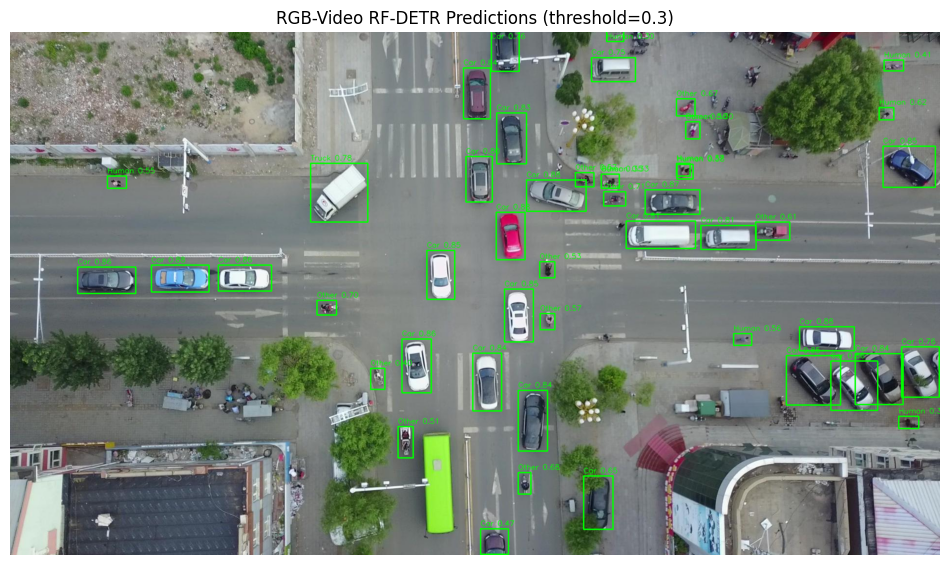

In [14]:
# ============================================================
# Cell 14: Live Inference Demo --> Load pinned RGB-video model
# + predict on one frame + visualize
# ============================================================

from pathlib import Path
import random
import torch
import cv2
import matplotlib.pyplot as plt
from rfdetr import RFDETRNano

# -----------------------------
# 1) Configure inputs
# -----------------------------
# Option A: set an explicit image path:
IMAGE_PATH = None  # e.g. PROJECT_ROOT / "visdrone-dataset-rgb-videos/val/sequences/<seq>/<frame>.jpg"

# Option B: pick a random frame from the VisDrone-VID val split if IMAGE_PATH is None
DEFAULT_SEQUENCE_DIR = DATASET_STRUCTURE["val"]["sequences_dir"]

# Checkpoint: use the pinned BEST EMA checkpoint from rgb-video-training
CKPT_PATH = PROJECT_ROOT / "models" / "rgb-video-training" / "visdrone_rfdetr_nano_best_ema.pth"

# Fallback to latest resume if best EMA is unavailable
FALLBACK_CKPT_PATH = PROJECT_ROOT / "models" / "rgb-video-training" / "visdrone_rfdetr_nano_latest_resume.pth"

# Prediction threshold
THRESHOLD = 0.30

# -----------------------------
# 2) Resolve image path
# -----------------------------
if IMAGE_PATH is None:
    assert DEFAULT_SEQUENCE_DIR.exists(), f"Default sequence dir not found: {DEFAULT_SEQUENCE_DIR}"

    sequence_dirs = sorted([p for p in DEFAULT_SEQUENCE_DIR.iterdir() if p.is_dir()])
    assert len(sequence_dirs) > 0, f"No sequence folders found in: {DEFAULT_SEQUENCE_DIR}"

    rng = random.Random(SEED)
    chosen_sequence = rng.choice(sequence_dirs)

    frame_files = sorted(chosen_sequence.glob("*.jpg"))
    assert len(frame_files) > 0, f"No .jpg frames found in: {chosen_sequence}"

    image_path = rng.choice(frame_files)
else:
    image_path = Path(IMAGE_PATH)

assert image_path.exists(), f"Image path does not exist: {image_path}"
print("Image:", image_path)

# -----------------------------
# 3) Resolve checkpoint path
# -----------------------------
if CKPT_PATH.exists():
    resolved_ckpt = CKPT_PATH
elif FALLBACK_CKPT_PATH.exists():
    resolved_ckpt = FALLBACK_CKPT_PATH
else:
    raise FileNotFoundError(
        "No rgb-video-training checkpoint found.\n"
        f"Tried:\n- {CKPT_PATH}\n- {FALLBACK_CKPT_PATH}"
    )

device = "cuda" if torch.cuda.is_available() else "cpu"

# Cache the model so repeated runs don't reload weights
global _RFD_MODEL, _RFD_CKPT
if "_RFD_MODEL" not in globals() or "_RFD_CKPT" not in globals() or _RFD_CKPT != str(resolved_ckpt):
    print("Loading model from checkpoint (this happens once per kernel)...")
    _RFD_MODEL = RFDETRNano(num_classes=NUM_CLASSES, pretrain_weights=str(resolved_ckpt))
    _RFD_CKPT = str(resolved_ckpt)

# Move underlying torch model to device
_RFD_MODEL.model.model.to(device)
_RFD_MODEL.model.model.eval()

print("Loaded checkpoint:", resolved_ckpt.name)
print("Device:", device)
print("Canonical classes:", PHASE3_CLASS_NAMES)

# -----------------------------
# 4) Predict
# -----------------------------
det = _RFD_MODEL.predict(str(image_path), threshold=THRESHOLD)

boxes = det.xyxy
scores = det.confidence
class_ids = det.class_id

print(f"Detections: {len(boxes)} (threshold={THRESHOLD})")

# -----------------------------
# 5) Visualize
# -----------------------------
img = cv2.imread(str(image_path))
if img is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for box, score, cls in zip(boxes, scores, class_ids):
    x1, y1, x2, y2 = map(int, box.tolist())
    cls = int(cls)

    label = class_id_to_name(cls)
    text = f"{label} {float(score):.2f}"

    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        img_rgb,
        text,
        (x1, max(15, y1 - 6)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA
    )

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"RGB-Video RF-DETR Predictions (threshold={THRESHOLD})")
plt.show()